In [17]:
import pandas as pd
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from adjustText import adjust_text

In [18]:
def load_problematic_file(file_path):
    """Handle files with encoding issues by reading as binary and cleaning"""
    try:
        with open(file_path, 'rb') as f:
            content = f.read()
        
        # Try to decode with error handling
        try:
            text = content.decode('utf-8', errors='ignore')
        except:
            text = content.decode('latin-1', errors='ignore')
        
        # Clean the text and parse JSON
        cleaned_text = text.strip()
        return json.loads(cleaned_text)
    except Exception as e:
        print(f"Failed to load {file_path} even with binary reading: {e}")
        return None

In [19]:
# Set up the data directory
OUTPUT_DIR = Path("output/bf-v1")

In [20]:
# Function to load all results into a dataframe
def load_all_results(output_dir):
    """Load all JSON results from the output directory into a pandas DataFrame"""
    all_results = []
    failed_files = []
    
    # Iterate through all experiment directories
    for exp_dir in output_dir.iterdir():
        if exp_dir.is_dir():
            
            # Load all JSON files in this experiment directory and its subdirectories
            for json_file in exp_dir.rglob("*.json"):
                # experiment_id is the relative directory path (top dir + subdirs)
                experiment_id = json_file.parent.relative_to(output_dir).as_posix()
                try:
                    # Try different encodings to handle special characters
                    encodings_to_try = ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']
                    data = None
                    
                    for encoding in encodings_to_try:
                        try:
                            with open(json_file, 'r', encoding=encoding) as f:
                                data = json.load(f)
                            break
                        except UnicodeDecodeError:
                            continue
                        except json.JSONDecodeError as e:
                            print(f"JSON decode error in {json_file} with {encoding}: {e}")
                            continue
                    
                    if data is not None:
                        # Add experiment_id to the data
                        data['experiment_id'] = experiment_id
                        all_results.append(data)
                    else:
                        # Try the binary reading approach as last resort
                        print(f"Trying binary reading for {json_file}")
                        data = load_problematic_file(json_file)
                        if data is not None:
                            data['experiment_id'] = experiment_id
                            all_results.append(data)
                        else:
                            failed_files.append(str(json_file))
                            print(f"Failed to load {json_file} with any method")
                    
                except Exception as e:
                    failed_files.append(str(json_file))
                    print(f"Error loading {json_file}: {e}")

    print(f"\nSuccessfully loaded: {len(all_results)} files")
    print(f"Failed to load: {len(failed_files)} files")
    if failed_files:
        print("Failed files:", failed_files)
    
    return pd.DataFrame(all_results)

# Load all results
print("Loading all results from output/bf-v1...")
df = load_all_results(OUTPUT_DIR)
print(f"Loaded {len(df)} results")
print(f"Columns: {list(df.columns)}")
print(f"Shape: {df.shape}")

Loading all results from output/bf-v1...

Successfully loaded: 1000 files
Failed to load: 0 files
Loaded 1000 results
Columns: ['prompt_id', 'input_image_path', 'user_prompt', 'model_provider', 'model_name', 'input_chars', 'input_tokens', 'output_chars', 'output_tokens', 'ttft_ms', 'total_latency_ms', 'response_text', 'http_status', 'error_category', 'error_message', 'temperature', 'top_p', 'experiment_id']
Shape: (1000, 18)


In [21]:
# Show basic info about the loaded data
if len(df) > 0:
    print(f"\nUnique models: {df['model_name'].nunique()}")
    print(f"Unique experiments: {df['experiment_id'].nunique()}")
    print(f"Model providers: {df['model_provider'].unique()}")
else:
    print("No data loaded successfully!")


Unique models: 10
Unique experiments: 100
Model providers: ['anthropic' 'openai' 'grok']


In [22]:
# Check non-completed experiments (internet errors)
non_completed = df[df['http_status'] != 200]
print(f"\nNon-completed experiments: {len(non_completed)}")
print(non_completed[['experiment_id', 'model_name', 'http_status', 'error_message']])


Non-completed experiments: 0
Empty DataFrame
Columns: [experiment_id, model_name, http_status, error_message]
Index: []


In [23]:
# Parse the response text to extract the bf predictions
def parse_response(response_text):
    """Parse the JSON response to extract bf prediction"""
    try:
        # Clean the response text and parse JSON
        # Remove any extra whitespace and parse
        cleaned_response = response_text.strip()
        parsed = json.loads(cleaned_response)
        prediction = int(parsed.get('burst-fracture-present', None))

        # Only count valid prediction
        if prediction != 0 and prediction != 1 :
            return None
        else:
            return prediction
    except:
        return None

# Add parsed predictions to the dataframe
df['burst_fracture_prediction'] = df['response_text'].apply(parse_response)

print("=== Response Parsing Results ===")
print(f"Successfully parsed responses: {df['burst_fracture_prediction'].notna().sum()}")
print(f"Failed to parse: {df['burst_fracture_prediction'].isna().sum()}")

=== Response Parsing Results ===
Successfully parsed responses: 628
Failed to parse: 372


In [24]:
# Load data from bf-v2
print("=== Loading Data from bf-v2 ===")
OUTPUT_DIR_V2 = Path("output/bf-v2")

# Load all results from v2
print("Loading all results from output/bf-v2...")
df_v2 = load_all_results(OUTPUT_DIR_V2)
print(f"Loaded {len(df_v2)} results from v2")
print(f"Columns: {list(df_v2.columns)}")
print(f"Shape: {df_v2.shape}")

# Parse predictions for v2
df_v2['burst_fracture_prediction'] = df_v2['response_text'].apply(parse_response)
print(f"Successfully parsed v2 responses: {df_v2['burst_fracture_prediction'].notna().sum()}")
print(f"Failed to parse v2: {df_v2['burst_fracture_prediction'].isna().sum()}")

=== Loading Data from bf-v2 ===
Loading all results from output/bf-v2...

Successfully loaded: 1000 files
Failed to load: 0 files
Loaded 1000 results from v2
Columns: ['prompt_id', 'input_image_path', 'user_prompt', 'model_provider', 'model_name', 'input_chars', 'input_tokens', 'output_chars', 'output_tokens', 'ttft_ms', 'total_latency_ms', 'response_text', 'http_status', 'error_category', 'error_message', 'temperature', 'top_p', 'experiment_id']
Shape: (1000, 18)
Successfully parsed v2 responses: 639
Failed to parse v2: 361


In [25]:
# Check non-completed experiments v2 (internet errors)
non_completed = df_v2[df_v2['http_status'] != 200]
print(f"\nNon-completed experiments: {len(non_completed)}")
print(non_completed[['experiment_id', 'model_name', 'http_status', 'error_message']])


Non-completed experiments: 0
Empty DataFrame
Columns: [experiment_id, model_name, http_status, error_message]
Index: []


In [26]:
# Merge v1 and v2 datasets for later comparison
print("=== Merging v1 and v2 Datasets ===")

# Add version identifier to each dataset
df['version'] = 'v1'
df_v2['version'] = 'v2'

# Combine both datasets
df_combined = pd.concat([df, df_v2], ignore_index=True)
print(f"Combined dataset shape: {df_combined.shape}")
print(f"Version distribution: {df_combined['version'].value_counts()}")

# Create a mapping for easy comparison
print("\n=== Creating Comparison Mapping ===")
comparison_data = []

for model_name in df_combined['model_name'].unique():
    model_v1 = df_combined[(df_combined['model_name'] == model_name) & (df_combined['version'] == 'v1')]
    model_v2 = df_combined[(df_combined['model_name'] == model_name) & (df_combined['version'] == 'v2')]
    
    print(f"\n{model_name}:")
    print(f"  V1 experiments: {len(model_v1)}")
    print(f"  V2 experiments: {len(model_v2)}")
    
    # Find common experiment IDs
    v1_experiments = set(model_v1['experiment_id'].unique())
    v2_experiments = set(model_v2['experiment_id'].unique())
    common_experiments = v1_experiments.intersection(v2_experiments)
    
    print(f"  Common experiments: {len(common_experiments)}")
    
    if len(common_experiments) > 0:
        # Create comparison pairs
        for exp_id in common_experiments:
            v1_row = model_v1[model_v1['experiment_id'] == exp_id].iloc[0]
            v2_row = model_v2[model_v2['experiment_id'] == exp_id].iloc[0]
            
            comparison_data.append({
                'model_name': model_name,
                'experiment_id': exp_id,
                'v1_prediction': v1_row['burst_fracture_prediction'],
                'v2_prediction': v2_row['burst_fracture_prediction'],
                'v1_response_text': v1_row['response_text'],
                'v2_response_text': v2_row['response_text'],
                'v1_parsed_success': pd.notna(v1_row['burst_fracture_prediction']),
                'v2_parsed_success': pd.notna(v2_row['burst_fracture_prediction']),
                'v1_latency': v1_row['total_latency_ms'],
                'v2_latency': v2_row['total_latency_ms']
            })

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_data)
print(f"\nCreated comparison dataset with {len(comparison_df)} experiment pairs")
print(f"Models in comparison: {comparison_df['model_name'].unique()}")
print(f"Shape: {comparison_df.shape}")

=== Merging v1 and v2 Datasets ===
Combined dataset shape: (2000, 20)
Version distribution: version
v1    1000
v2    1000
Name: count, dtype: int64

=== Creating Comparison Mapping ===

claude-3-7-sonnet-20250219:
  V1 experiments: 100
  V2 experiments: 100
  Common experiments: 100

claude-opus-4-1-20250805:
  V1 experiments: 100
  V2 experiments: 100
  Common experiments: 100

claude-opus-4-20250514:
  V1 experiments: 100
  V2 experiments: 100
  Common experiments: 100

claude-sonnet-4-20250514:
  V1 experiments: 100
  V2 experiments: 100
  Common experiments: 100

gpt-4.1:
  V1 experiments: 100
  V2 experiments: 100
  Common experiments: 100

gpt-4o:
  V1 experiments: 100
  V2 experiments: 100
  Common experiments: 100

gpt-5-chat-latest:
  V1 experiments: 100
  V2 experiments: 100
  Common experiments: 100

gpt-5:
  V1 experiments: 100
  V2 experiments: 100
  Common experiments: 100

grok-4-fast-reasoning:
  V1 experiments: 100
  V2 experiments: 100
  Common experiments: 100

o1:
 

In [27]:
df_combined.shape

(2000, 20)

In [28]:
# Create separate dataframes for each model
print("=== Creating separate dataframes for each model ===")

# Get unique models
unique_models = df_combined['model_name'].unique()
print(f"Found {len(unique_models)} unique models: {unique_models}")

# Create a dictionary to store dataframes for each model
model_dataframes = {}

for model in unique_models:
    # Filter data for this specific model
    model_df = df_combined[df_combined['model_name'] == model].copy()
    
    # Add some derived columns
    model_df['latency_seconds'] = model_df['total_latency_ms'] / 1000
    model_df['ttft_seconds'] = model_df['ttft_ms'] / 1000
    model_df['has_error'] = model_df['error_message'].notna()
    
    # Store in dictionary
    model_dataframes[model] = model_df
    
    print(f"Model: {model}")
    print(f"  - Shape: {model_df.shape}")
    print(f"  - Experiments: {model_df['experiment_id'].nunique()}")
    print(f"  - Successful runs: {model_df['burst_fracture_prediction'].notna().sum()}")
    print(f"  - Error rate: {model_df['has_error'].mean():.2%}")
    print(f"  - Avg latency: {model_df['total_latency_ms'].mean():.2f} ms")
    print()

print(f"Created {len(model_dataframes)} separate dataframes")

=== Creating separate dataframes for each model ===
Found 10 unique models: ['claude-3-7-sonnet-20250219' 'claude-opus-4-1-20250805'
 'claude-opus-4-20250514' 'claude-sonnet-4-20250514' 'gpt-4.1' 'gpt-4o'
 'gpt-5-chat-latest' 'gpt-5' 'grok-4-fast-reasoning' 'o1']
Model: claude-3-7-sonnet-20250219
  - Shape: (200, 23)
  - Experiments: 100
  - Successful runs: 200
  - Error rate: 0.00%
  - Avg latency: 1168.35 ms

Model: claude-opus-4-1-20250805
  - Shape: (200, 23)
  - Experiments: 100
  - Successful runs: 39
  - Error rate: 0.00%
  - Avg latency: 5292.63 ms

Model: claude-opus-4-20250514
  - Shape: (200, 23)
  - Experiments: 100
  - Successful runs: 49
  - Error rate: 0.00%
  - Avg latency: 4856.34 ms

Model: claude-sonnet-4-20250514
  - Shape: (200, 23)
  - Experiments: 100
  - Successful runs: 135
  - Error rate: 0.00%
  - Avg latency: 2743.97 ms

Model: gpt-4.1
  - Shape: (200, 23)
  - Experiments: 100
  - Successful runs: 82
  - Error rate: 0.00%
  - Avg latency: 46047.08 ms

Model

In [29]:
# Save each model's dataframe to separate CSV files
print("=== Saving individual model dataframes ===")

for model_name, model_df in model_dataframes.items():
    filename = f"reports/csv_reports/bf_{model_name}_results.csv"
    
    # Save to CSV
    model_df.to_csv(filename, index=False)
    print(f"Saved {model_name} -> {filename} ({model_df.shape[0]} rows)")

print(f"\nSaved {len(model_dataframes)} individual model dataframes")

=== Saving individual model dataframes ===
Saved claude-3-7-sonnet-20250219 -> reports/csv_reports/bf_claude-3-7-sonnet-20250219_results.csv (200 rows)
Saved claude-opus-4-1-20250805 -> reports/csv_reports/bf_claude-opus-4-1-20250805_results.csv (200 rows)
Saved claude-opus-4-20250514 -> reports/csv_reports/bf_claude-opus-4-20250514_results.csv (200 rows)
Saved claude-sonnet-4-20250514 -> reports/csv_reports/bf_claude-sonnet-4-20250514_results.csv (200 rows)
Saved gpt-4.1 -> reports/csv_reports/bf_gpt-4.1_results.csv (200 rows)
Saved gpt-4o -> reports/csv_reports/bf_gpt-4o_results.csv (200 rows)
Saved gpt-5-chat-latest -> reports/csv_reports/bf_gpt-5-chat-latest_results.csv (200 rows)
Saved gpt-5 -> reports/csv_reports/bf_gpt-5_results.csv (200 rows)
Saved grok-4-fast-reasoning -> reports/csv_reports/bf_grok-4-fast-reasoning_results.csv (200 rows)
Saved o1 -> reports/csv_reports/bf_o1_results.csv (200 rows)

Saved 10 individual model dataframes


=== Creating average latency plot ===


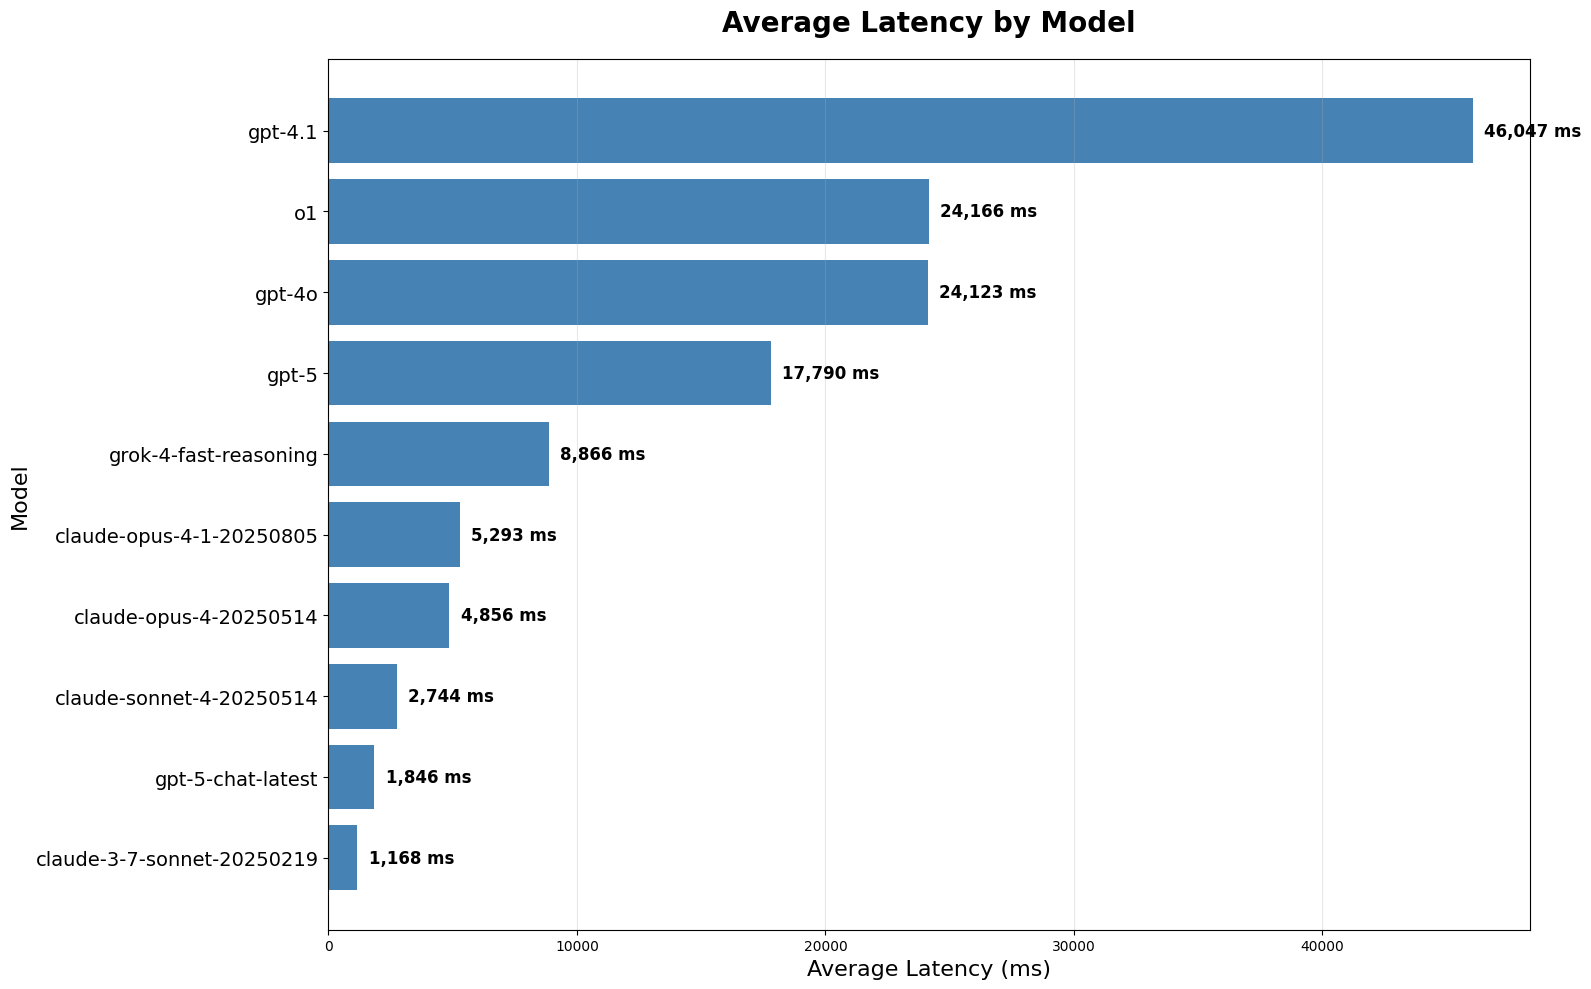

Saved average latency plot to: reports/plots/bf_average_latency.png


In [30]:
# Plot average latency by model
print("=== Creating average latency plot ===")

# Calculate average latency for each model
avg_latency_data = {}
for model in unique_models:
    avg_latency_data[model] = model_dataframes[model]['total_latency_ms'].mean()

# Convert to Series and sort
avg_latency_series = pd.Series(avg_latency_data).sort_values(ascending=True)

# Create the plot
fig, ax = plt.subplots(figsize=(16, 10))

bars = ax.barh(range(len(avg_latency_series)), avg_latency_series.values, color='steelblue')
ax.set_title('Average Latency by Model', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Average Latency (ms)', fontsize=16)
ax.set_ylabel('Model', fontsize=16)
ax.set_yticks(range(len(avg_latency_series)))
ax.set_yticklabels(avg_latency_series.index, fontsize=14)
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, avg_latency_series.values)):
    ax.text(value + max(avg_latency_series.values) * 0.01, i, f'{value:,.0f} ms', 
            ha='left', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()

# Ensure the directory exists
Path('reports/plots').mkdir(parents=True, exist_ok=True)

plt.savefig('reports/plots/bf_average_latency.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved average latency plot to: reports/plots/bf_average_latency.png")

# Task Completion Analysis

In [31]:
# Calculate success rate (successful runs / total experiments) for each model
print("=== Model Success Rate Analysis ===")

success_rates = {}
for model_name, model_df in model_dataframes.items():
    total_experiments = len(model_df)
    successful_runs = model_df['burst_fracture_prediction'].notna().sum()
    success_rate = successful_runs / total_experiments if total_experiments > 0 else 0
    fail_rate = 1 - success_rate
    
    success_rates[model_name] = {
        'total_experiments': total_experiments,
        'successful_runs': successful_runs,
        'failed_runs': total_experiments - successful_runs,
        'success_rate': success_rate,
        'fail_rate': fail_rate
    }
    
    print(f"{model_name}:")
    print(f"  Total experiments: {total_experiments}")
    print(f"  Successful runs: {successful_runs}")
    print(f"  Failed runs: {total_experiments - successful_runs}")
    print(f"  Success rate: {success_rate:.2%}")
    print(f"  Fail rate: {fail_rate:.2%}")
    print()

# Convert to DataFrame
success_df = pd.DataFrame(success_rates).T
print("Success rate summary:")
print(success_df[['total_experiments', 'successful_runs', 'failed_runs', 'success_rate', 'fail_rate']])

=== Model Success Rate Analysis ===
claude-3-7-sonnet-20250219:
  Total experiments: 200
  Successful runs: 200
  Failed runs: 0
  Success rate: 100.00%
  Fail rate: 0.00%

claude-opus-4-1-20250805:
  Total experiments: 200
  Successful runs: 39
  Failed runs: 161
  Success rate: 19.50%
  Fail rate: 80.50%

claude-opus-4-20250514:
  Total experiments: 200
  Successful runs: 49
  Failed runs: 151
  Success rate: 24.50%
  Fail rate: 75.50%

claude-sonnet-4-20250514:
  Total experiments: 200
  Successful runs: 135
  Failed runs: 65
  Success rate: 67.50%
  Fail rate: 32.50%

gpt-4.1:
  Total experiments: 200
  Successful runs: 82
  Failed runs: 118
  Success rate: 41.00%
  Fail rate: 59.00%

gpt-4o:
  Total experiments: 200
  Successful runs: 14
  Failed runs: 186
  Success rate: 7.00%
  Fail rate: 93.00%

gpt-5-chat-latest:
  Total experiments: 200
  Successful runs: 198
  Failed runs: 2
  Success rate: 99.00%
  Fail rate: 1.00%

gpt-5:
  Total experiments: 200
  Successful runs: 200
  F

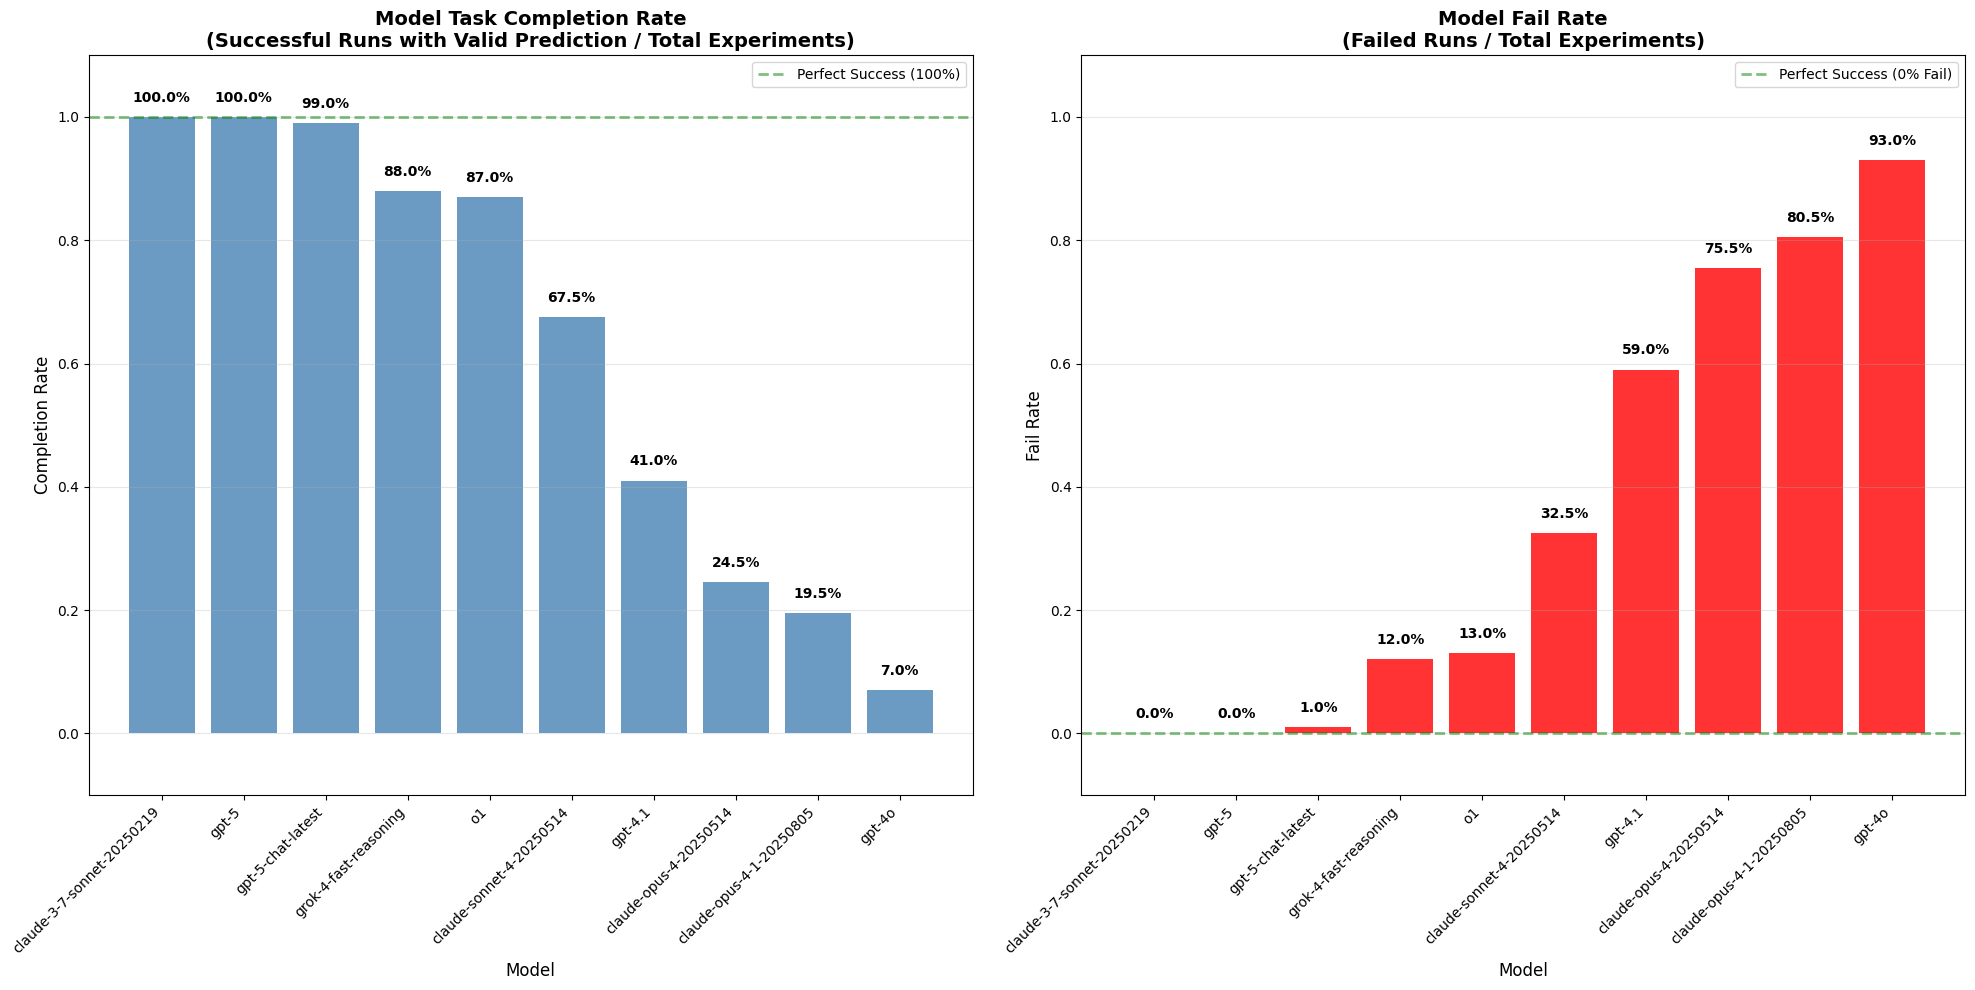

Saved success/fail rate plots to: reports/plots/bf_model_success_fail_rates.png


In [32]:
# Create success rate visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot 1: Completion Rate (Successful runs / Total experiments)
success_data = success_df['success_rate'].sort_values(ascending=False)
bars1 = ax1.bar(range(len(success_data)), success_data.values, color='steelblue', alpha=0.8)
ax1.set_title('Model Task Completion Rate\n(Successful Runs with Valid Prediction / Total Experiments)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Completion Rate', fontsize=12)
ax1.set_xticks(range(len(success_data)))
ax1.set_xticklabels(success_data.index, rotation=45, ha='right')
ax1.set_ylim([-0.1, 1.1])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars1, success_data.values)):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{value:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add horizontal line at 100% success rate
ax1.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Perfect Success (100%)')
ax1.legend()

# Plot 2: Fail Rate (Failed runs / Total experiments)
fail_data = success_df['fail_rate'].sort_values(ascending=True)
bars2 = ax2.bar(range(len(fail_data)), fail_data.values, color='red', alpha=0.8)
ax2.set_title('Model Fail Rate\n(Failed Runs / Total Experiments)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('Fail Rate', fontsize=12)
ax2.set_xticks(range(len(fail_data)))
ax2.set_xticklabels(fail_data.index, rotation=45, ha='right')
ax2.set_ylim([-0.1, 1.1])
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars2, fail_data.values)):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{value:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add horizontal line at 0% fail rate
ax2.axhline(y=0.0, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Perfect Success (0% Fail)')
ax2.legend()

plt.tight_layout()
plt.savefig('reports/plots/bf_model_success_fail_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved success/fail rate plots to: reports/plots/bf_model_success_fail_rates.png")

C:\Users\nguyetpvt\AppData\Local\Temp\ipykernel_24416\690143766.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=45, ha='right')


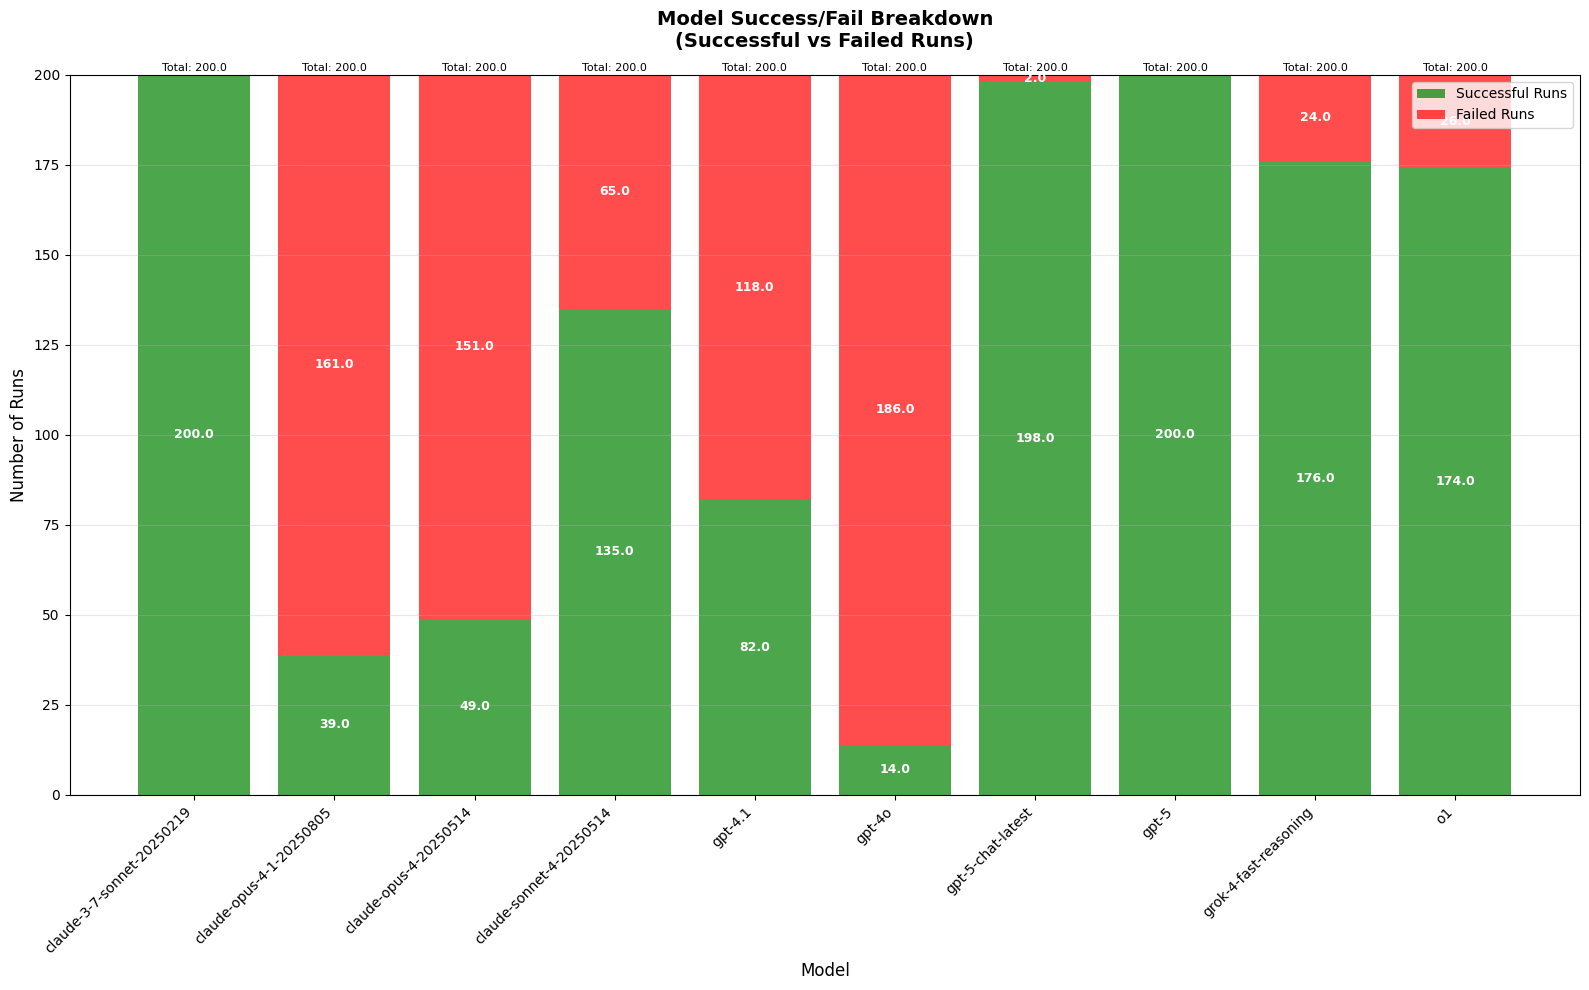

Saved success/fail breakdown plot to: reports/plots/bf_model_success_fail_breakdown.png
Saved success rate data to: reports/csv_reports/bf_model_success_rates.csv


In [33]:
# Create a detailed success/fail breakdown plot
fig, ax = plt.subplots(figsize=(16, 10))

# Prepare data for stacked bar chart
models = success_df.index
successful_runs = success_df['successful_runs'].values
failed_runs = success_df['failed_runs'].values
total_experiments = success_df['total_experiments'].values

# Create stacked bar chart
bars_success = ax.bar(models, successful_runs, color='green', alpha=0.7, label='Successful Runs')
bars_fail = ax.bar(models, failed_runs, bottom=successful_runs, color='red', alpha=0.7, label='Failed Runs')

# Add value labels on bars
for i, (model, success, fail, total) in enumerate(zip(models, successful_runs, failed_runs, total_experiments)):
    # Label for successful runs
    if success > 0:
        ax.text(i, success/2, f'{success}', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    
    # Label for failed runs
    if fail > 0:
        ax.text(i, success + fail/2, f'{fail}', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    
    # Total label at the top
    ax.text(i, total + 0.5, f'Total: {total}', ha='center', va='bottom', fontsize=8, color='black')

ax.set_title('Model Success/Fail Breakdown\n(Successful vs Failed Runs)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Number of Runs', fontsize=12)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('reports/plots/bf_model_success_fail_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved success/fail breakdown plot to: reports/plots/bf_model_success_fail_breakdown.png")

# Save success rate data to CSV
success_df.to_csv('reports/csv_reports/bf_model_success_rates.csv')
print("Saved success rate data to: reports/csv_reports/bf_model_success_rates.csv")

Invalid responses available for text analysis: 372


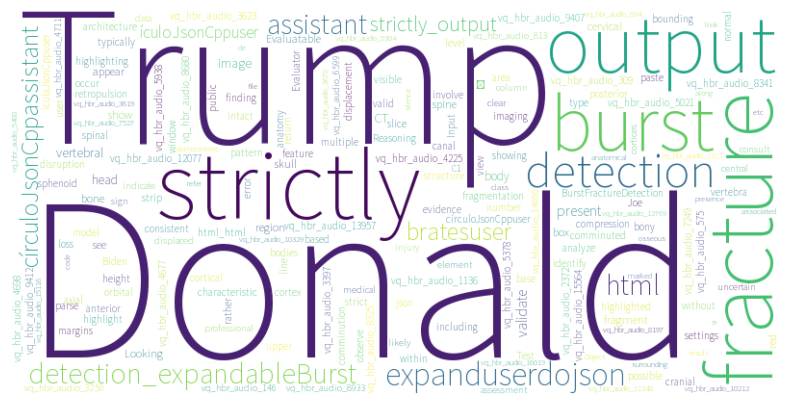

Saved plot to: reports/plots/bf_invalid_response_word_cloud.png


In [34]:
# Visualize invalid response_text content 
from wordcloud import WordCloud
from matplotlib import ft2font
from pathlib import Path

# Select invalid responses (failed to parse)
invalid_df = df[df['burst_fracture_prediction'].isna() & df['response_text'].notna()].copy()
print(f"Invalid responses available for text analysis: {len(invalid_df)}")

texts = "\n".join(invalid_df['response_text'].astype(str).tolist())

# Resolve primary CJK font and fallback regular font
primary_font_path = Path("C://Users//nguyetpvt//AppData//Local//Microsoft//Windows//Fonts//NotoSansCJK-VF.ttf.ttc")
fallback_font_path = Path("C://Users//nguyetpvt//AppData//Local//Microsoft//Windows//Fonts//NotoSans-VariableFont_wdth,wght.ttf")


# Helper: determine if a word is fully supported by a font (all glyphs available)
def word_supported_by_font(word, font_path: Path) -> bool:
    try:
        ft = ft2font.FT2Font(str(font_path))
        for ch in word:
            # Skip whitespace/newlines
            if ch.isspace():
                continue
            if ft.get_char_index(ord(ch)) == 0:
                return False
        return True
    except Exception:
        # If we can't validate, assume unsupported to be safe
        return False


# Generate two word clouds and composite so that unsupported words render with fallback font
wc_kwargs = dict(width=800, height=400, background_color='white', collocations=False, random_state=42)

wc = WordCloud(font_path=str(primary_font_path) if primary_font_path else None, **wc_kwargs).generate(texts)

# Display the generated image using Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  # Turn off axis labels
plt.show()
plt.imsave('reports/plots/bf_invalid_response_word_cloud.png', wc)
plt.show()

print("Saved plot to: reports/plots/bf_invalid_response_word_cloud.png")

# Accuracy Analysis

In [35]:
# Load ground truth data
print("=== Loading Ground Truth Data ===")
ground_truth_df = pd.read_csv('../eda/bf_ground_truth.csv')
print(f"Ground truth shape: {ground_truth_df.shape}")
print(f"Ground truth columns: {list(ground_truth_df.columns)}")
print(f"Ground truth distribution: {ground_truth_df['Burst_Fracture'].value_counts()}")

=== Loading Ground Truth Data ===
Ground truth shape: (100, 3)
Ground truth columns: ['StudyInstanceUID', 'slice_number', 'Burst_Fracture']
Ground truth distribution: Burst_Fracture
1    95
0     5
Name: count, dtype: int64


In [36]:
df_combined["experiment_id"]

0       1.2.826.0.1.3680043.12998/slice_194
1       1.2.826.0.1.3680043.12998/slice_194
2       1.2.826.0.1.3680043.12998/slice_194
3       1.2.826.0.1.3680043.12998/slice_194
4       1.2.826.0.1.3680043.12998/slice_194
                       ...                 
1995     1.2.826.0.1.3680043.8043/slice_174
1996     1.2.826.0.1.3680043.8043/slice_174
1997     1.2.826.0.1.3680043.8043/slice_174
1998     1.2.826.0.1.3680043.8043/slice_174
1999     1.2.826.0.1.3680043.8043/slice_174
Name: experiment_id, Length: 2000, dtype: object

In [38]:
# Create mapping from experiment_id to ground truth
print("=== Creating Experiment ID to Ground Truth Mapping ===")

# Extract experiment ID from the name format "CQ500-CT-{experiment_id}"
ground_truth_df['experiment_id'] = ground_truth_df['StudyInstanceUID'].astype(str) + "/slice_" + ground_truth_df["slice_number"].astype(str)

# Create mapping dictionary
experiment_to_ground_truth = dict(zip(ground_truth_df['experiment_id'], ground_truth_df['Burst_Fracture']))

print(f"Created mapping for {len(experiment_to_ground_truth)} experiments")
print(f"Sample mappings: {dict(list(experiment_to_ground_truth.items())[:10])}")

# Add ground truth to the main dataframe
df_combined['ground_truth'] = df_combined['experiment_id'].map(experiment_to_ground_truth)

print(f"\nDataframe with ground truth shape: {df_combined.shape}")
print(f"Ground truth distribution in data: {df_combined['ground_truth'].value_counts()}")
print(f"Missing ground truth values: {df_combined['ground_truth'].isna().sum()}")

=== Creating Experiment ID to Ground Truth Mapping ===
Created mapping for 100 experiments
Sample mappings: {'1.2.826.0.1.3680043.12998/slice_194': 0, '1.2.826.0.1.3680043.12998/slice_195': 1, '1.2.826.0.1.3680043.12998/slice_196': 1, '1.2.826.0.1.3680043.12998/slice_197': 1, '1.2.826.0.1.3680043.12998/slice_198': 1, '1.2.826.0.1.3680043.12998/slice_199': 1, '1.2.826.0.1.3680043.12998/slice_200': 1, '1.2.826.0.1.3680043.12998/slice_201': 1, '1.2.826.0.1.3680043.12998/slice_202': 1, '1.2.826.0.1.3680043.12998/slice_203': 1}

Dataframe with ground truth shape: (2000, 21)
Ground truth distribution in data: ground_truth
1    1900
0     100
Name: count, dtype: int64
Missing ground truth values: 0


In [41]:
# Accuracy Metrics Calculation
print("=== Calculating Metrics by Model (Accuracy, TPR, FPR, TNR, FNR, Confusion Matrix) ===")

# Store metrics for each model
all_metrics = []
accuracy_data = []

for model_name, model_df in model_dataframes.items():
    # Add ground truth to model dataframe
    model_df['ground_truth'] = model_df['experiment_id'].astype(str).map(experiment_to_ground_truth)
    
    # Include all data where ground truth is available (treat NaN predictions as wrong)
    valid_data = model_df[model_df['ground_truth'].notna()].copy()
    
    if len(valid_data) > 0:
        y_true = valid_data['ground_truth'].astype(int)
        # For NaN predictions, treat them as wrong predictions (use opposite of ground truth)
        y_pred = valid_data['burst_fracture_prediction'].fillna(-1).astype(int)

        # Calculate metrics
        accuracy = accuracy_score(y_true, y_pred)
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, -1])

        def compute_metrics_multiclass(cm, labels):
            metrics = []
            total = cm.sum()

            for i, label in enumerate(labels):
                TP = cm[i, i]
                FN = cm[i, :].sum() - TP
                FP = cm[:, i].sum() - TP
                TN = total - (TP + FP + FN)

                metrics.append({
                    "class": label,
                    "TP": TP,
                    "FP": FP,
                    "FN": FN,
                    "TN": TN,
                    "TPR": TP / (TP + FN) if TP + FN > 0 else 0,
                    "FPR": FP / (FP + TN) if FP + TN > 0 else 0,
                    "TNR": TN / (TN + FP) if TN + FP > 0 else 0,
                    "FNR": FN / (FN + TP) if FN + TP > 0 else 0,
                })

            return pd.DataFrame(metrics)
        
        
        metrics_df = compute_metrics_multiclass(cm, [0, 1, -1])

        metrics_df["model"] = model_name
        all_metrics.append(metrics_df)

        accuracy_data.append({
            "model": model_name,
            "accuracy": accuracy,
            "total_samples": len(valid_data)
        })
        
        print(f"\n{model_name}:")
        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Samples:   {len(valid_data)}")
    else:
        print(f"\n{model_name}: No valid data for evaluation")

# Convert to DataFrame for easy viewing
metrics_df = pd.concat(all_metrics, ignore_index=True)
accuracy_df = pd.DataFrame(accuracy_data)
print("\n=== Updated Metrics Summary DataFrame ===")
print(metrics_df)
print(accuracy_df)

=== Calculating Metrics by Model (Accuracy, TPR, FPR, TNR, FNR, Confusion Matrix) ===

claude-3-7-sonnet-20250219:
  Accuracy:  0.7300
  Samples:   200

claude-opus-4-1-20250805:
  Accuracy:  0.0250
  Samples:   200

claude-opus-4-20250514:
  Accuracy:  0.0250
  Samples:   200

claude-sonnet-4-20250514:
  Accuracy:  0.2400
  Samples:   200

gpt-4.1:
  Accuracy:  0.2000
  Samples:   200

gpt-4o:
  Accuracy:  0.0150
  Samples:   200

gpt-5-chat-latest:
  Accuracy:  0.7800
  Samples:   200

gpt-5:
  Accuracy:  0.2200
  Samples:   200

grok-4-fast-reasoning:
  Accuracy:  0.7950
  Samples:   200

o1:
  Accuracy:  0.1900
  Samples:   200

=== Updated Metrics Summary DataFrame ===
    class   TP   FP   FN   TN       TPR       FPR       TNR       FNR  \
0       0    3   47    7  143  0.300000  0.247368  0.752632  0.700000   
1       1  143    7   47    3  0.752632  0.700000  0.300000  0.247368   
2      -1    0    0    0  200  0.000000  0.000000  1.000000  0.000000   
3       0    1   34    9 

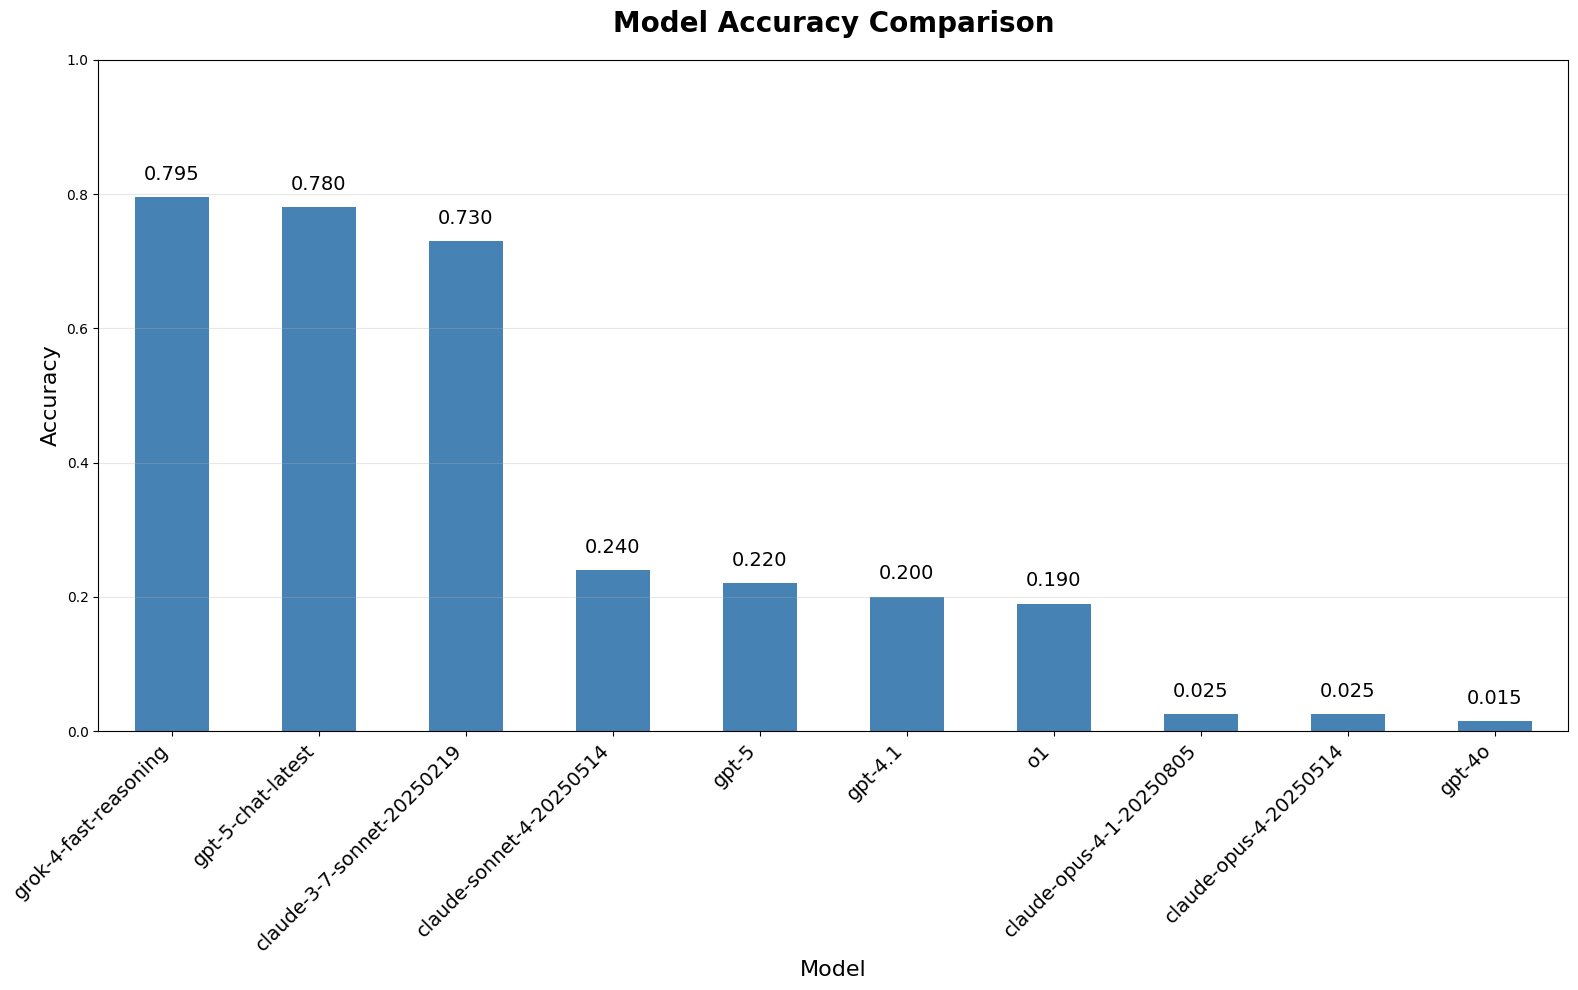

Saved updated metrics plots to: reports/plots/bf_model_accuracy_metrics.png


In [42]:
# 1. Accuracy comparison
fig, ax = plt.subplots(figsize=(16, 10))

accuracy_data = accuracy_df['accuracy'].sort_values(ascending=False)
accuracy_data.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Model Accuracy Comparison', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Model', fontsize=16)
ax.set_ylabel('Accuracy', fontsize=16)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(accuracy_df.iloc[accuracy_data.index]["model"], rotation=45, ha='right', fontsize=14)
for i, v in enumerate(accuracy_data):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=14)
    
plt.tight_layout()
plt.savefig('reports/plots/bf_model_accuracy_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved updated metrics plots to: reports/plots/bf_model_accuracy_metrics.png")

=== Creating average TPR, FPR, TNR, FNR Visualizations ===


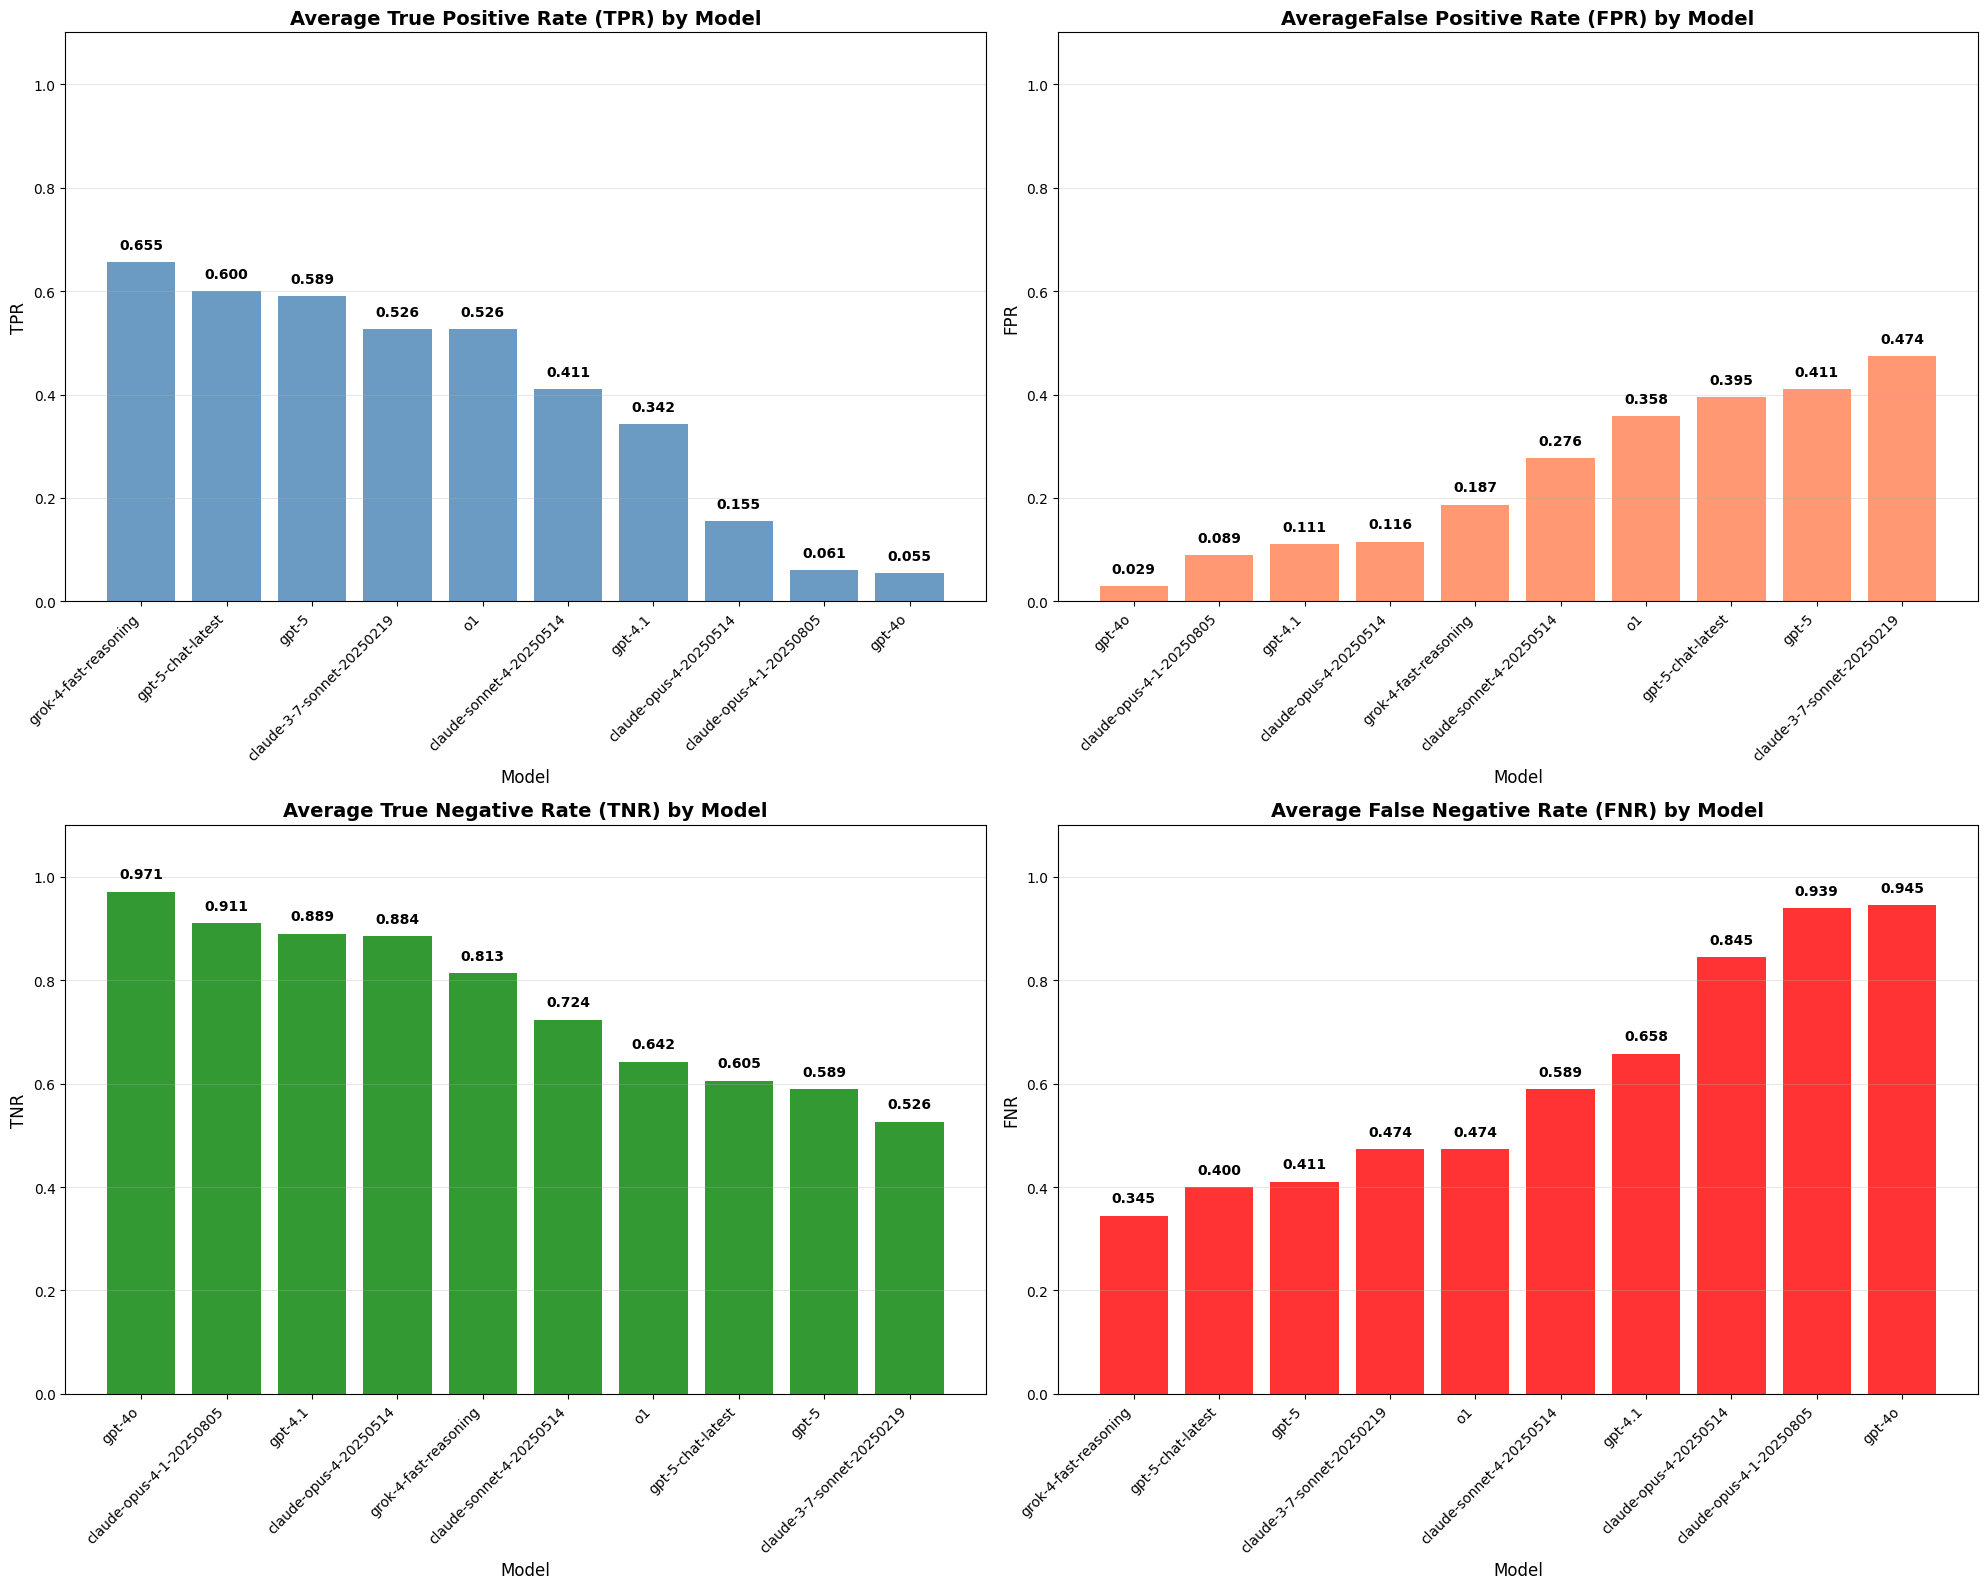

In [45]:
# Plot average TPR, FPR, TNR, FNR by model and by class
print("=== Creating average TPR, FPR, TNR, FNR Visualizations ===")

# Filter out class -1 (failed predictions) for main analysis
metrics_df_filtered = metrics_df[metrics_df['class'] != -1].copy()

# Create plots by model
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. TPR by Model
ax1 = axes[0, 0]
tpr_by_model = metrics_df_filtered.groupby('model')['TPR'].mean().sort_values(ascending=False)
bars1 = ax1.bar(range(len(tpr_by_model)), tpr_by_model.values, color='steelblue', alpha=0.8)
ax1.set_title('Average True Positive Rate (TPR) by Model', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('TPR', fontsize=12)
ax1.set_xticks(range(len(tpr_by_model)))
ax1.set_xticklabels(tpr_by_model.index, rotation=45, ha='right')
ax1.set_ylim([0, 1.1])
ax1.grid(axis='y', alpha=0.3)
for i, (bar, value) in enumerate(zip(bars1, tpr_by_model.values)):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. FPR by Model
ax2 = axes[0, 1]
fpr_by_model = metrics_df_filtered.groupby('model')['FPR'].mean().sort_values(ascending=True)
bars2 = ax2.bar(range(len(fpr_by_model)), fpr_by_model.values, color='coral', alpha=0.8)
ax2.set_title('AverageFalse Positive Rate (FPR) by Model', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('FPR', fontsize=12)
ax2.set_xticks(range(len(fpr_by_model)))
ax2.set_xticklabels(fpr_by_model.index, rotation=45, ha='right')
ax2.set_ylim([0, 1.1])
ax2.grid(axis='y', alpha=0.3)
for i, (bar, value) in enumerate(zip(bars2, fpr_by_model.values)):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. TNR by Model
ax3 = axes[1, 0]
tnr_by_model = metrics_df_filtered.groupby('model')['TNR'].mean().sort_values(ascending=False)
bars3 = ax3.bar(range(len(tnr_by_model)), tnr_by_model.values, color='green', alpha=0.8)
ax3.set_title('Average True Negative Rate (TNR) by Model', fontsize=14, fontweight='bold')
ax3.set_xlabel('Model', fontsize=12)
ax3.set_ylabel('TNR', fontsize=12)
ax3.set_xticks(range(len(tnr_by_model)))
ax3.set_xticklabels(tnr_by_model.index, rotation=45, ha='right')
ax3.set_ylim([0, 1.1])
ax3.grid(axis='y', alpha=0.3)
for i, (bar, value) in enumerate(zip(bars3, tnr_by_model.values)):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. FNR by Model
ax4 = axes[1, 1]
fnr_by_model = metrics_df_filtered.groupby('model')['FNR'].mean().sort_values(ascending=True)
bars4 = ax4.bar(range(len(fnr_by_model)), fnr_by_model.values, color='red', alpha=0.8)
ax4.set_title('Average False Negative Rate (FNR) by Model', fontsize=14, fontweight='bold')
ax4.set_xlabel('Model', fontsize=12)
ax4.set_ylabel('FNR', fontsize=12)
ax4.set_xticks(range(len(fnr_by_model)))
ax4.set_xticklabels(fnr_by_model.index, rotation=45, ha='right')
ax4.set_ylim([0, 1.1])
ax4.grid(axis='y', alpha=0.3)
for i, (bar, value) in enumerate(zip(bars4, fnr_by_model.values)):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/plots/bf_avg_metrics_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

=== Creating Comprehensive Metrics Plot by Model and Class ===


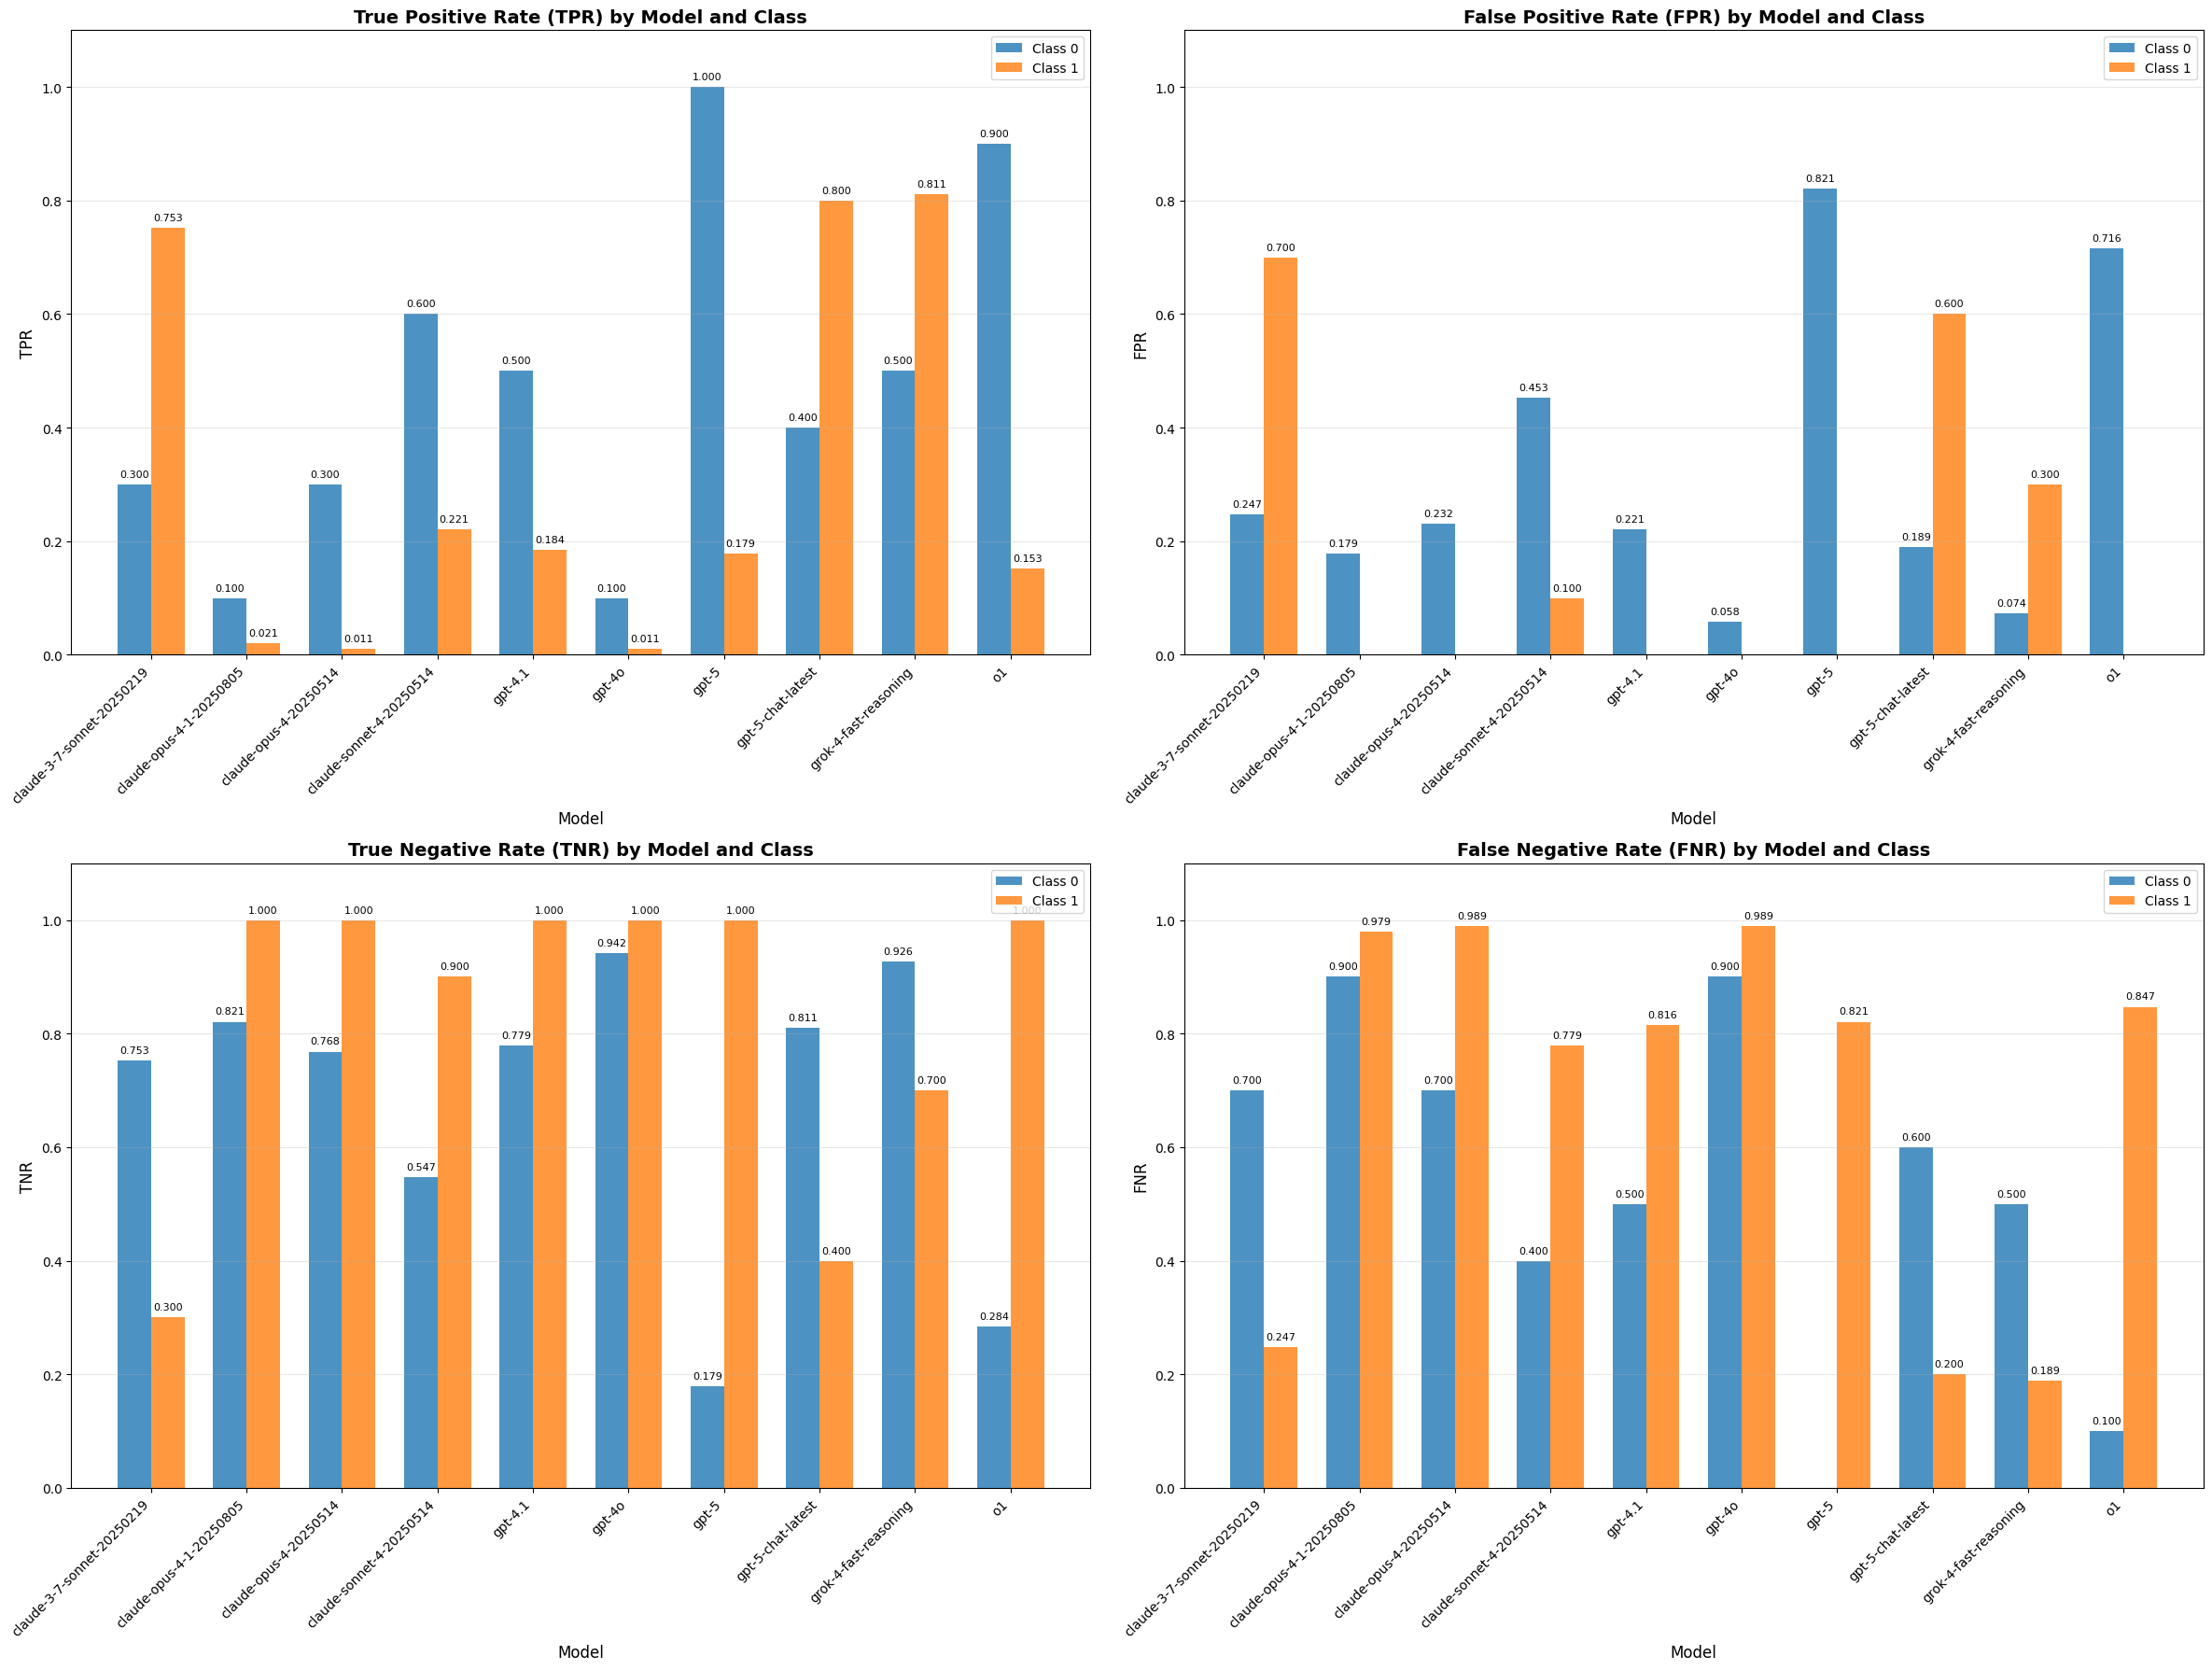

Saved comprehensive metrics plot to: reports/plots/bf_comprehensive_metrics_by_model_and_class.png


In [46]:
# Comprehensive plot: TPR, FPR, TNR, FNR grouped by model with details for each class
print("=== Creating Comprehensive Metrics Plot by Model and Class ===")

# Filter out class -1 (failed predictions) for main analysis
metrics_df_filtered = metrics_df[metrics_df['class'] != -1].copy()

# Create a comprehensive 2x2 subplot showing all metrics, with each model showing class 0 and class 1
fig, axes = plt.subplots(2, 2, figsize=(24, 18))

models = sorted(metrics_df_filtered['model'].unique())
classes = sorted(metrics_df_filtered['class'].unique())
x = np.arange(len(models))
width = 0.35  # Width of bars for each class

# 1. TPR by Model and Class
ax1 = axes[0, 0]
for i, cls in enumerate(classes):
    tpr_values = [metrics_df_filtered[(metrics_df_filtered['model'] == m) & 
                                      (metrics_df_filtered['class'] == cls)]['TPR'].values[0] 
                  if len(metrics_df_filtered[(metrics_df_filtered['model'] == m) & 
                                            (metrics_df_filtered['class'] == cls)]) > 0 
                  else 0 for m in models]
    offset = (i - 0.5) * width
    bars = ax1.bar(x + offset, tpr_values, width, label=f'Class {int(cls)}', alpha=0.8)
    # Add value labels
    for bar, val in zip(bars, tpr_values):
        if val > 0.01:
            ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax1.set_title('True Positive Rate (TPR) by Model and Class', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('TPR', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.1])

# 2. FPR by Model and Class
ax2 = axes[0, 1]
for i, cls in enumerate(classes):
    fpr_values = [metrics_df_filtered[(metrics_df_filtered['model'] == m) & 
                                      (metrics_df_filtered['class'] == cls)]['FPR'].values[0] 
                  if len(metrics_df_filtered[(metrics_df_filtered['model'] == m) & 
                                            (metrics_df_filtered['class'] == cls)]) > 0 
                  else 0 for m in models]
    offset = (i - 0.5) * width
    bars = ax2.bar(x + offset, fpr_values, width, label=f'Class {int(cls)}', alpha=0.8)
    # Add value labels
    for bar, val in zip(bars, fpr_values):
        if val > 0.01:
            ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax2.set_title('False Positive Rate (FPR) by Model and Class', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('FPR', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1.1])

# 3. TNR by Model and Class
ax3 = axes[1, 0]
for i, cls in enumerate(classes):
    tnr_values = [metrics_df_filtered[(metrics_df_filtered['model'] == m) & 
                                      (metrics_df_filtered['class'] == cls)]['TNR'].values[0] 
                  if len(metrics_df_filtered[(metrics_df_filtered['model'] == m) & 
                                            (metrics_df_filtered['class'] == cls)]) > 0 
                  else 0 for m in models]
    offset = (i - 0.5) * width
    bars = ax3.bar(x + offset, tnr_values, width, label=f'Class {int(cls)}', alpha=0.8)
    # Add value labels
    for bar, val in zip(bars, tnr_values):
        if val > 0.01:
            ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax3.set_title('True Negative Rate (TNR) by Model and Class', fontsize=14, fontweight='bold')
ax3.set_xlabel('Model', fontsize=12)
ax3.set_ylabel('TNR', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0, 1.1])

# 4. FNR by Model and Class
ax4 = axes[1, 1]
for i, cls in enumerate(classes):
    fnr_values = [metrics_df_filtered[(metrics_df_filtered['model'] == m) & 
                                      (metrics_df_filtered['class'] == cls)]['FNR'].values[0] 
                  if len(metrics_df_filtered[(metrics_df_filtered['model'] == m) & 
                                            (metrics_df_filtered['class'] == cls)]) > 0 
                  else 0 for m in models]
    offset = (i - 0.5) * width
    bars = ax4.bar(x + offset, fnr_values, width, label=f'Class {int(cls)}', alpha=0.8)
    # Add value labels
    for bar, val in zip(bars, fnr_values):
        if val > 0.01:
            ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax4.set_title('False Negative Rate (FNR) by Model and Class', fontsize=14, fontweight='bold')
ax4.set_xlabel('Model', fontsize=12)
ax4.set_ylabel('FNR', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig('reports/plots/bf_comprehensive_metrics_by_model_and_class.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved comprehensive metrics plot to: reports/plots/bf_comprehensive_metrics_by_model_and_class.png")


=== Creating Confusion Matrix Plots ===


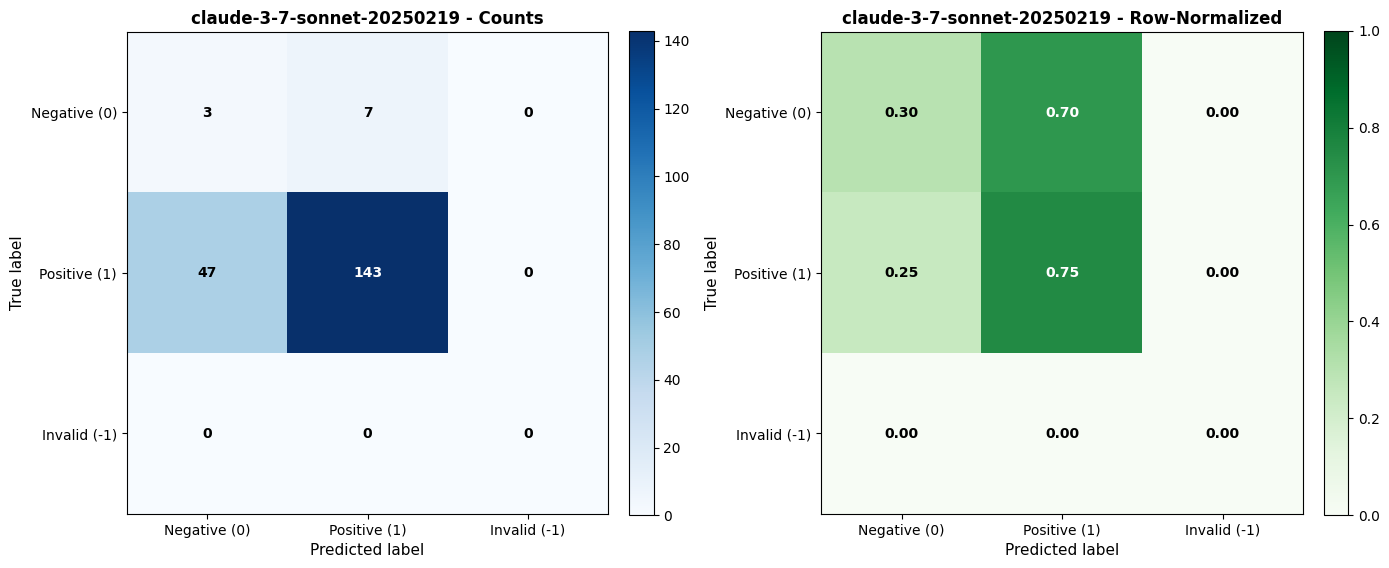

Saved confusion matrix plots to: reports/plots/bf_confusion_matrix_claude-3-7-sonnet-20250219_with_invalid.png


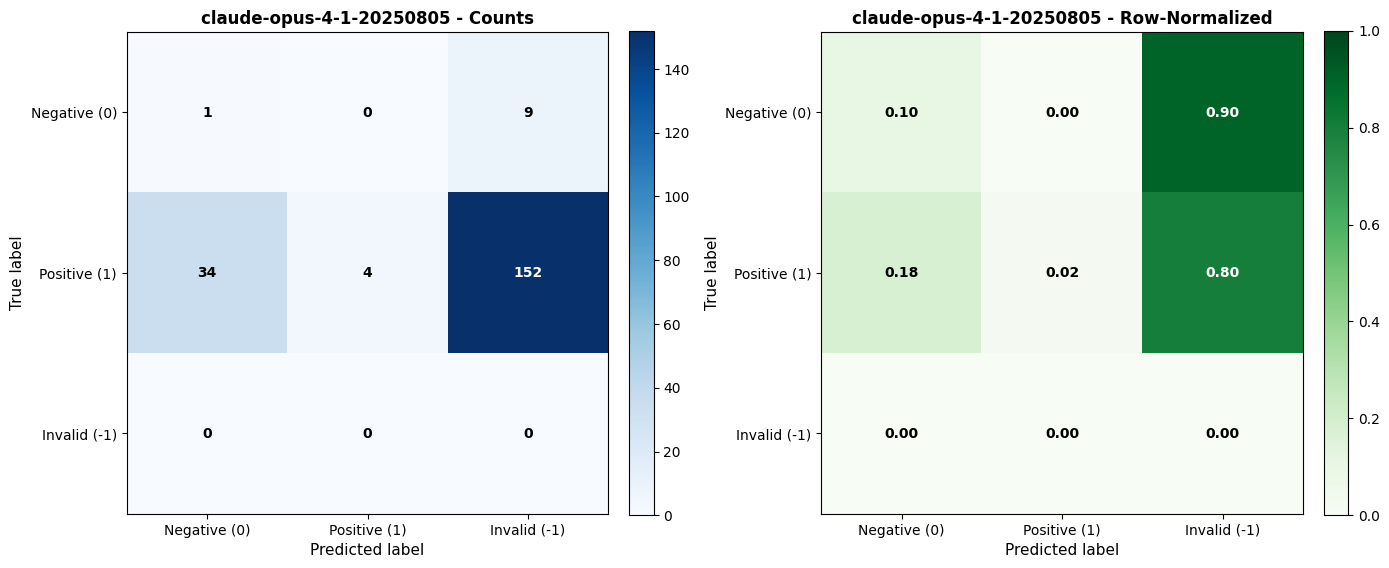

Saved confusion matrix plots to: reports/plots/bf_confusion_matrix_claude-opus-4-1-20250805_with_invalid.png


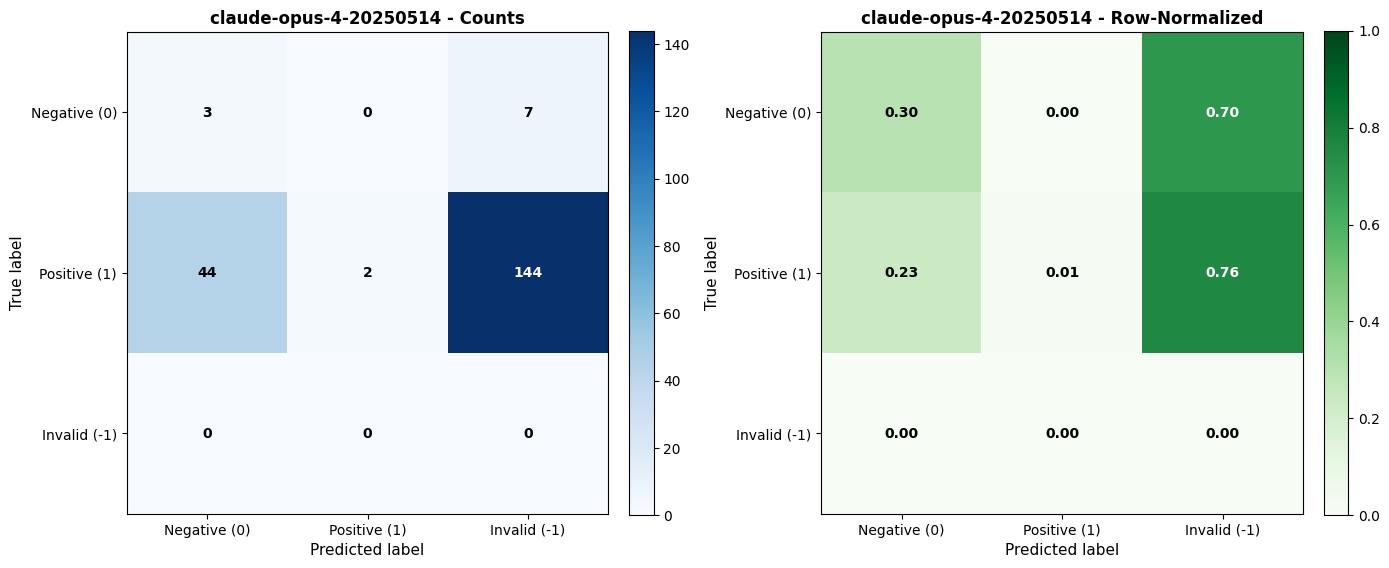

Saved confusion matrix plots to: reports/plots/bf_confusion_matrix_claude-opus-4-20250514_with_invalid.png


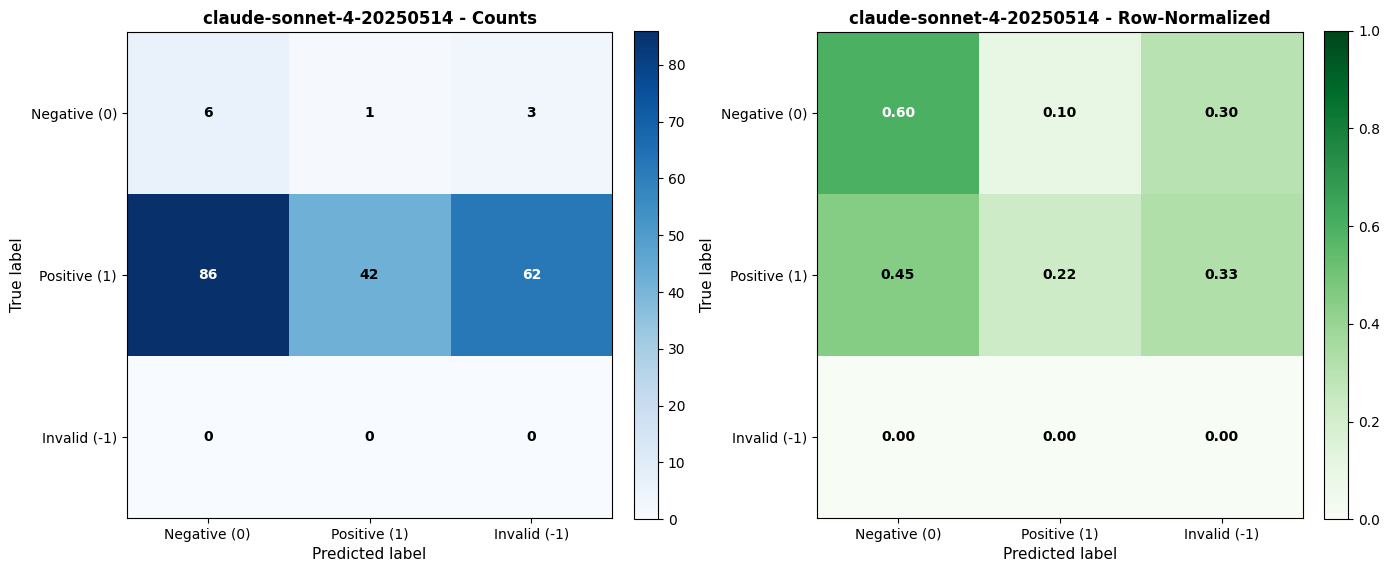

Saved confusion matrix plots to: reports/plots/bf_confusion_matrix_claude-sonnet-4-20250514_with_invalid.png


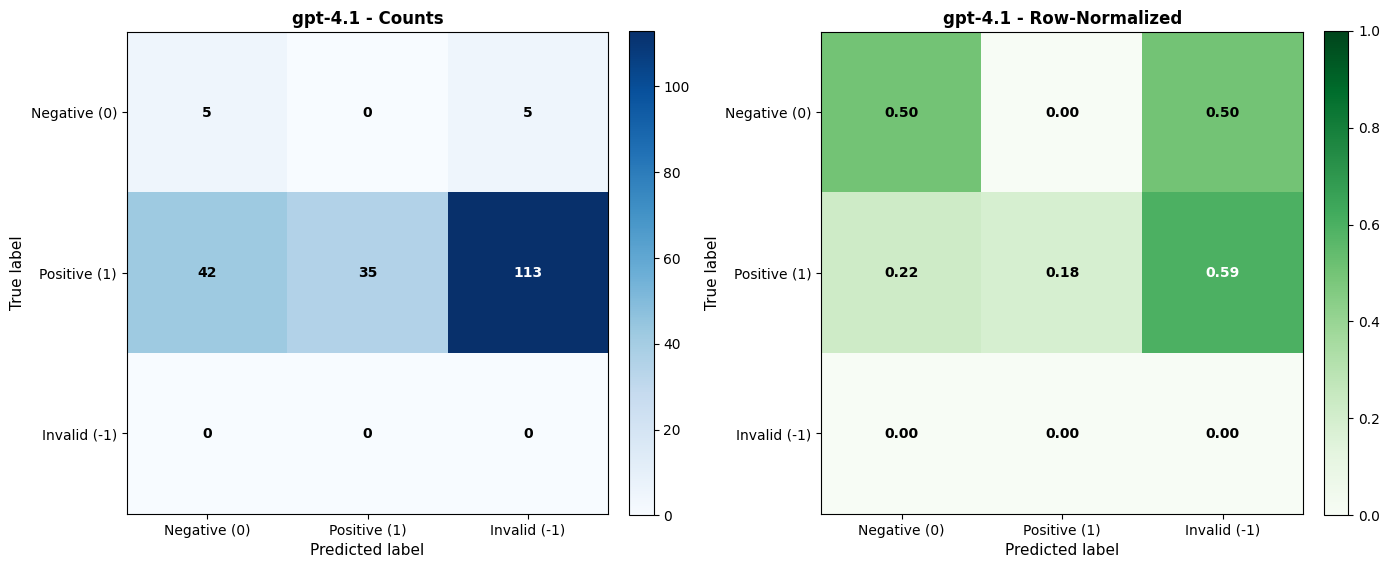

Saved confusion matrix plots to: reports/plots/bf_confusion_matrix_gpt-4.1_with_invalid.png


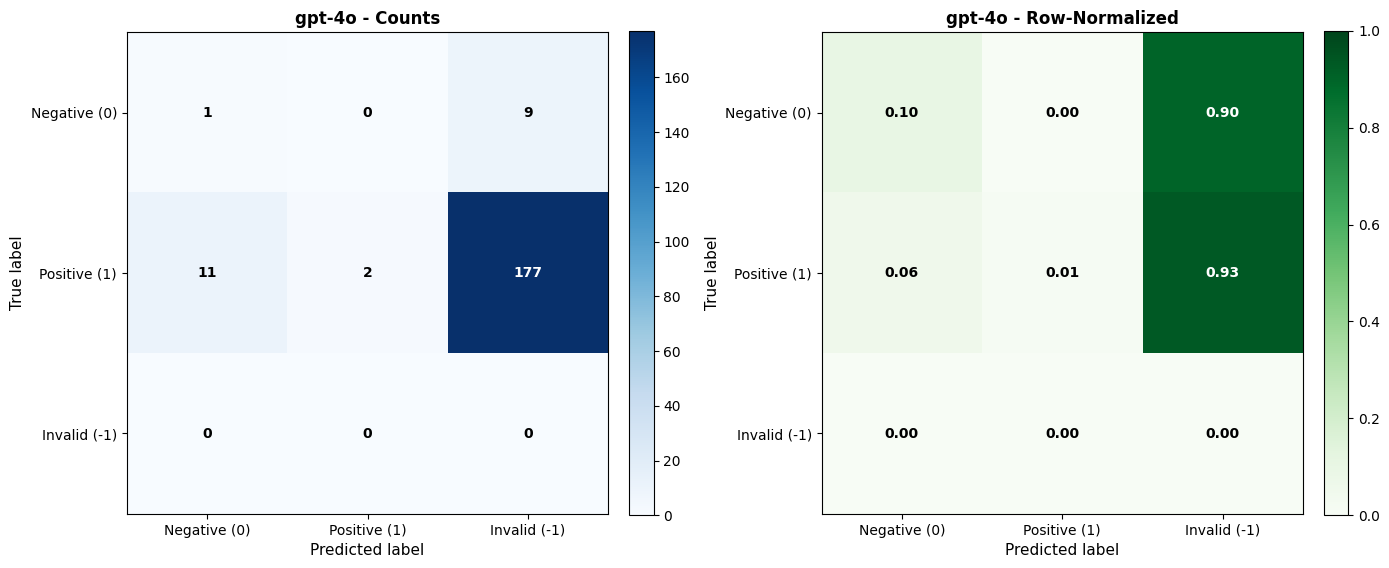

Saved confusion matrix plots to: reports/plots/bf_confusion_matrix_gpt-4o_with_invalid.png


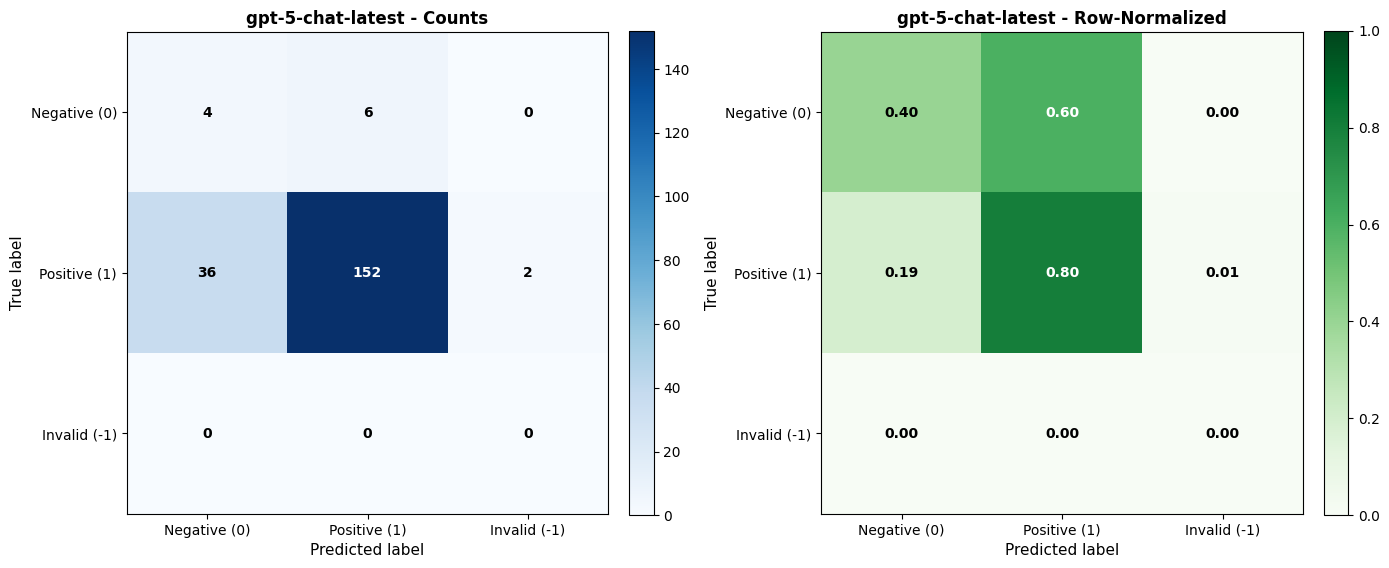

Saved confusion matrix plots to: reports/plots/bf_confusion_matrix_gpt-5-chat-latest_with_invalid.png


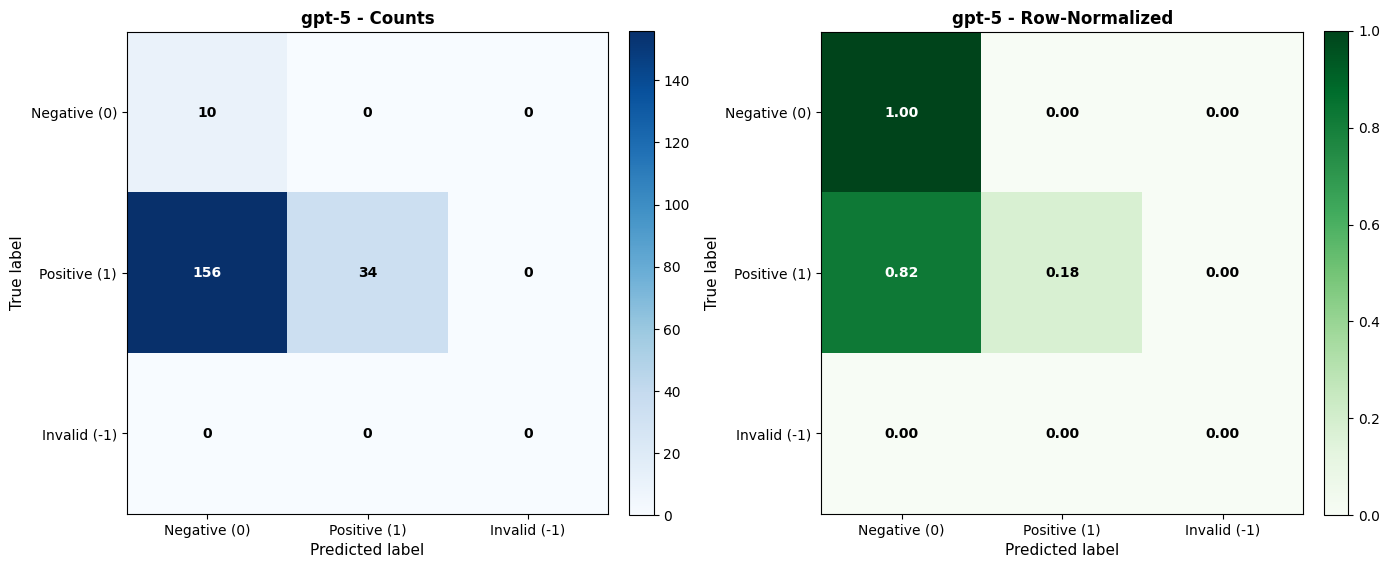

Saved confusion matrix plots to: reports/plots/bf_confusion_matrix_gpt-5_with_invalid.png


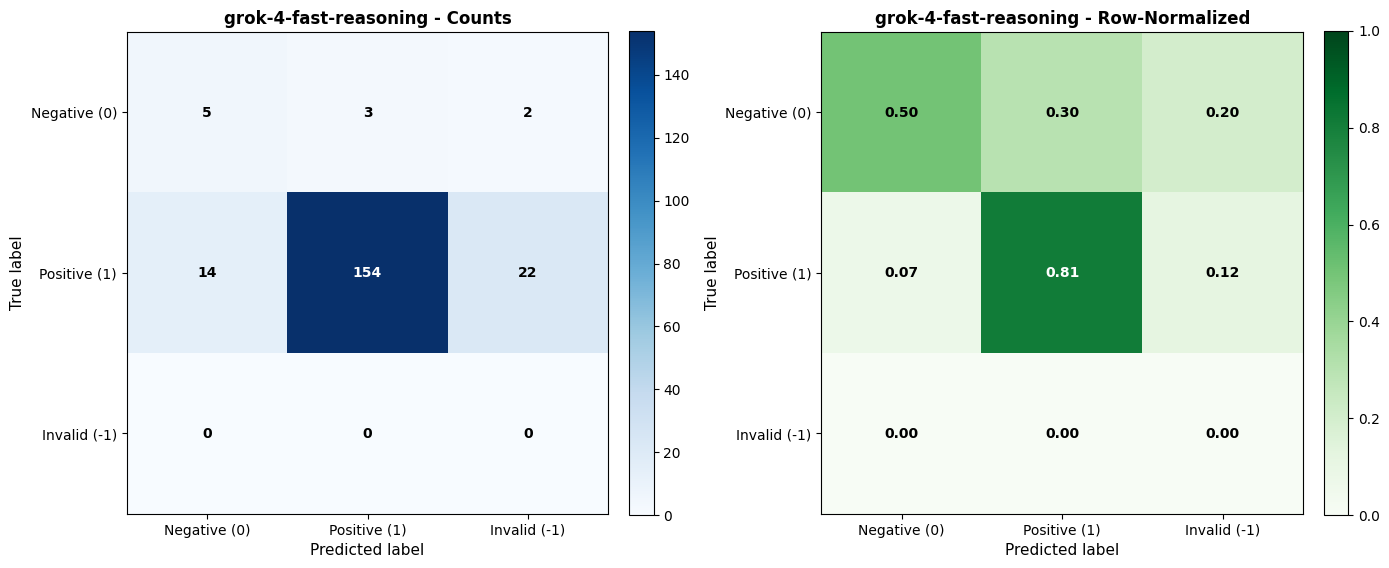

Saved confusion matrix plots to: reports/plots/bf_confusion_matrix_grok-4-fast-reasoning_with_invalid.png


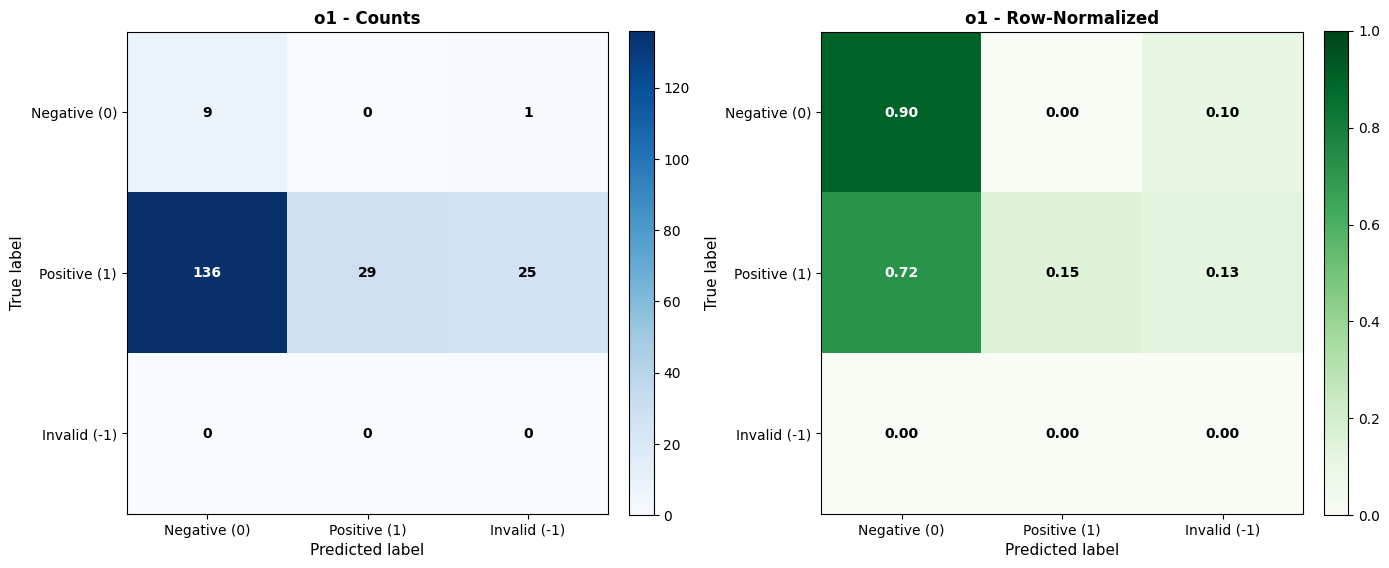

Saved confusion matrix plots to: reports/plots/bf_confusion_matrix_o1_with_invalid.png


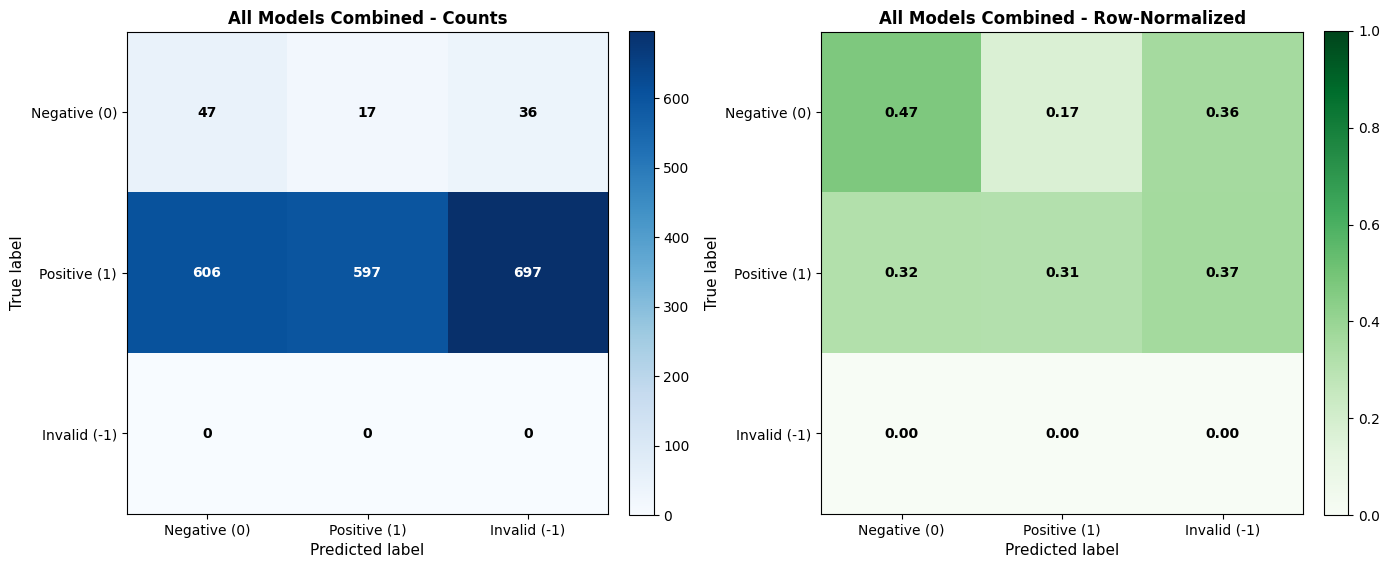

Saved confusion matrix plots to: reports/plots/bf_confusion_matrix_all_models_with_invalid.png

=== Confusion Matrix Plots with Invalid Class Complete ===


In [47]:
# Plot confusion matrices including invalid class (-1)
print("=== Creating Confusion Matrix Plots ===")

# Helper function to plot confusion matrix with invalid class support
def plot_confusion_matrices_with_invalid(cm_counts, title_prefix, save_basename):
    labels = ['Negative (0)', 'Positive (1)', 'Invalid (-1)']
    tick_positions = [0, 1, 2]

    # Normalized by true label counts (row-wise)
    with np.errstate(invalid='ignore', divide='ignore'):
        row_sums = cm_counts.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm_counts, row_sums, out=np.zeros_like(cm_counts, dtype=float), where=row_sums!=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Counts heatmap
    im0 = axes[0].imshow(cm_counts, cmap='Blues')
    axes[0].set_title(f"{title_prefix} - Counts", fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted label', fontsize=11)
    axes[0].set_ylabel('True label', fontsize=11)
    axes[0].set_xticks(tick_positions)
    axes[0].set_yticks(tick_positions)
    axes[0].set_xticklabels(labels, fontsize=10)
    axes[0].set_yticklabels(labels, fontsize=10)
    # Annotate counts
    for i in range(cm_counts.shape[0]):
        for j in range(cm_counts.shape[1]):
            max_val = cm_counts.max()
            axes[0].text(j, i, f"{cm_counts[i, j]}", ha='center', va='center', 
                        color='white' if max_val > 0 and cm_counts[i, j] > max_val / 2 else 'black', 
                        fontsize=10, fontweight='bold')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # Normalized heatmap
    im1 = axes[1].imshow(cm_norm, cmap='Greens', vmin=0, vmax=1)
    axes[1].set_title(f"{title_prefix} - Row-Normalized", fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Predicted label', fontsize=11)
    axes[1].set_ylabel('True label', fontsize=11)
    axes[1].set_xticks(tick_positions)
    axes[1].set_yticks(tick_positions)
    axes[1].set_xticklabels(labels, fontsize=10)
    axes[1].set_yticklabels(labels, fontsize=10)
    # Annotate normalized values
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            axes[1].text(j, i, f"{cm_norm[i, j]:.2f}", ha='center', va='center', 
                        color='white' if cm_norm[i, j] > 0.5 else 'black', 
                        fontsize=10, fontweight='bold')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(f"reports/plots/{save_basename}.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved confusion matrix plots to: reports/plots/{save_basename}.png")

# Per-model confusion matrices including invalid predictions
for model_name, model_df in model_dataframes.items():
    # Ensure ground truth is present
    if 'ground_truth' not in model_df.columns:
        model_df['ground_truth'] = model_df['experiment_id'].astype(str).map(experiment_to_ground_truth)

    # Include all rows with ground truth (even if prediction is invalid/NaN)
    valid_gt = model_df['ground_truth'].notna()
    valid_df = model_df[valid_gt].copy()

    if len(valid_df) == 0:
        print(f"Skipping {model_name}: no ground truth available")
        continue

    y_true = valid_df['ground_truth'].astype(int)
    # Map NaN predictions to -1 (invalid)
    y_pred = valid_df['burst_fracture_prediction'].fillna(-1).astype(int)

    # Create confusion matrix with labels [0, 1, -1] to include invalid
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, -1])

    safe_model_name = str(model_name).replace('/', '-').replace(' ', '_')
    plot_confusion_matrices_with_invalid(cm, f"{model_name}", f"bf_confusion_matrix_{safe_model_name}_with_invalid")

# Overall confusion matrix across all models including invalid predictions
overall_df = df_combined[df_combined['ground_truth'].notna()].copy()
if len(overall_df) > 0:
    y_true_all = overall_df['ground_truth'].astype(int)
    # Map NaN predictions to -1 (invalid)
    y_pred_all = overall_df['burst_fracture_prediction'].fillna(-1).astype(int)
    cm_all = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1, -1])
    plot_confusion_matrices_with_invalid(cm_all, 'All Models Combined', 'bf_confusion_matrix_all_models_with_invalid')
else:
    print('No ground truth data available for confusion matrix.')

print("\n=== Confusion Matrix Plots with Invalid Class Complete ===")

In [48]:
# Save accuracy metrics data to CSV
metrics_df.to_csv('reports/csv_reports/bf_model_accuracy_metrics.csv')
print("Saved accuracy metrics data to: reports/csv_reports/bf_model_accuracy_metrics.csv")

Saved accuracy metrics data to: reports/csv_reports/bf_model_accuracy_metrics.csv


# Cost Analysis

In [49]:
# Define pricing per 1M tokens based on the provided cost information
pricing_data = {
    'gpt-4o': {'input': 2.5, 'output': 10.00},
    'gpt-4.1': {'input': 2.00, 'output': 8.00},
    'gpt-5': {'input': 1.25, 'output': 10.00},
    'gpt-5-chat-latest': {'input': 1.25, 'output': 10.00},
    'o1': {'input': 15.00, 'output': 60.00},
    'claude-opus-4-20250514': {'input': 15.00, 'output': 75.00},
    'claude-opus-4-1-20250805': {'input': 15.00, 'output': 75.00},
    'claude-sonnet-4-20250514': {'input': 3.00, 'output': 15.00},
    'claude-3-7-sonnet-latest': {'input': 3.00, 'output': 15.00},
    'grok-4-fast-reasoning': {'input': 0.2, 'output': 0.5}
}

In [50]:
# Cost Analysis - Token Usage and Pricing
print("=== Cost Analysis: Token Usage and Pricing ===")

# Calculate average input tokens per request for each model
print("\n=== Average Input Tokens per Request ===")
input_token_analysis = {}

for model_name, model_df in model_dataframes.items():
    if model_name in pricing_data:
        avg_input_tokens = model_df['input_tokens'].mean()
        input_token_analysis[model_name] = {
            'avg_input_tokens': avg_input_tokens,
            'std_input_tokens': model_df['input_tokens'].std(),
            'min_input_tokens': model_df['input_tokens'].min(),
            'max_input_tokens': model_df['input_tokens'].max(),
            'total_requests': len(model_df)
        }
        
        print(f"{model_name}:")
        print(f"  Average input tokens: {avg_input_tokens:.2f}")
        print(f"  Std deviation: {model_df['input_tokens'].std():.2f}")
        print(f"  Range: {model_df['input_tokens'].min():.0f} - {model_df['input_tokens'].max():.0f}")
        print(f"  Total requests: {len(model_df)}")
        print()

# Convert to DataFrame for easier analysis
input_token_df = pd.DataFrame(input_token_analysis).T

=== Cost Analysis: Token Usage and Pricing ===

=== Average Input Tokens per Request ===
claude-opus-4-1-20250805:
  Average input tokens: 853.00
  Std deviation: 0.00
  Range: 853 - 853
  Total requests: 200

claude-opus-4-20250514:
  Average input tokens: 853.00
  Std deviation: 0.00
  Range: 853 - 853
  Total requests: 200

claude-sonnet-4-20250514:
  Average input tokens: 853.00
  Std deviation: 0.00
  Range: 853 - 853
  Total requests: 200

gpt-4.1:
  Average input tokens: 939.00
  Std deviation: 0.00
  Range: 939 - 939
  Total requests: 200

gpt-4o:
  Average input tokens: 939.00
  Std deviation: 0.00
  Range: 939 - 939
  Total requests: 200

gpt-5-chat-latest:
  Average input tokens: 819.00
  Std deviation: 0.00
  Range: 819 - 819
  Total requests: 200

gpt-5:
  Average input tokens: 799.00
  Std deviation: 0.00
  Range: 799 - 799
  Total requests: 200

grok-4-fast-reasoning:
  Average input tokens: 599.00
  Std deviation: 0.00
  Range: 599 - 599
  Total requests: 200

o1:
  Ave

In [56]:
# Calculate average output tokens per request for each model
print("\n=== Average Output Tokens per Request ===")
output_token_analysis = {}

for model_name, model_df in model_dataframes.items():
    if model_name in pricing_data:
        avg_output_tokens = model_df['output_tokens'].mean()
        output_token_analysis[model_name] = {
            'avg_output_tokens': avg_output_tokens,
            'std_output_tokens': model_df['output_tokens'].std(),
            'min_output_tokens': model_df['output_tokens'].min(),
            'max_output_tokens': model_df['output_tokens'].max(),
            'total_requests': len(model_df)
        }
        
        print(f"{model_name}:")
        print(f"  Average output tokens: {avg_output_tokens:.2f}")
        print(f"  Std deviation: {model_df['output_tokens'].std():.2f}")
        print(f"  Range: {model_df['output_tokens'].min():.0f} - {model_df['output_tokens'].max():.0f}")
        print(f"  Total requests: {len(model_df)}")
        print()

# Convert to DataFrame for easier analysis
output_token_df = pd.DataFrame(output_token_analysis).T


=== Average Output Tokens per Request ===
claude-opus-4-1-20250805:
  Average output tokens: 94.17
  Std deviation: 45.90
  Range: 14 - 184
  Total requests: 200

claude-opus-4-20250514:
  Average output tokens: 89.42
  Std deviation: 49.16
  Range: 14 - 212
  Total requests: 200

claude-sonnet-4-20250514:
  Average output tokens: 41.45
  Std deviation: 41.84
  Range: 14 - 187
  Total requests: 200

gpt-4.1:
  Average output tokens: 4117.92
  Std deviation: 10590.03
  Range: 11 - 32768
  Total requests: 200

gpt-4o:
  Average output tokens: 763.46
  Std deviation: 2983.01
  Range: 9 - 16384
  Total requests: 200

gpt-5-chat-latest:
  Average output tokens: 9.49
  Std deviation: 6.03
  Range: 9 - 94
  Total requests: 200

gpt-5:
  Average output tokens: 822.38
  Std deviation: 313.97
  Range: 282 - 1629
  Total requests: 200

grok-4-fast-reasoning:
  Average output tokens: 10.09
  Std deviation: 0.69
  Range: 9 - 14
  Total requests: 200

o1:
  Average output tokens: 1350.66
  Std devi

In [57]:
# Calculate average cost per request for each model
print("\n=== Average Cost per Request ===")
cost_analysis = {}

for model_name, model_df in model_dataframes.items():
    if model_name in pricing_data:
        # Get pricing for this model
        input_price_per_1m = pricing_data[model_name]['input']
        output_price_per_1m = pricing_data[model_name]['output']
        
        # Calculate costs for each request
        input_costs = (model_df['input_tokens'] / 1_000_000) * input_price_per_1m
        output_costs = (model_df['output_tokens'] / 1_000_000) * output_price_per_1m
        total_costs = input_costs + output_costs
        
        # Calculate averages
        avg_input_cost = input_costs.mean()
        avg_output_cost = output_costs.mean()
        avg_total_cost = total_costs.mean()
        
        cost_analysis[model_name] = {
            'avg_input_cost': avg_input_cost,
            'avg_output_cost': avg_output_cost,
            'avg_total_cost': avg_total_cost,
            'input_price_per_1m': input_price_per_1m,
            'output_price_per_1m': output_price_per_1m,
            'total_requests': len(model_df)
        }
        
        print(f"{model_name}:")
        print(f"  Input cost per 1M tokens: ${input_price_per_1m:.2f}")
        print(f"  Output cost per 1M tokens: ${output_price_per_1m:.2f}")
        print(f"  Average input cost per request: ${avg_input_cost:.6f}")
        print(f"  Average output cost per request: ${avg_output_cost:.6f}")
        print(f"  Average total cost per request: ${avg_total_cost:.6f}")
        print(f"  Total requests: {len(model_df)}")
        print()

# Convert to DataFrame for easier analysis
cost_df = pd.DataFrame(cost_analysis).T


=== Average Cost per Request ===
claude-opus-4-1-20250805:
  Input cost per 1M tokens: $15.00
  Output cost per 1M tokens: $75.00
  Average input cost per request: $0.012795
  Average output cost per request: $0.007063
  Average total cost per request: $0.019858
  Total requests: 200

claude-opus-4-20250514:
  Input cost per 1M tokens: $15.00
  Output cost per 1M tokens: $75.00
  Average input cost per request: $0.012795
  Average output cost per request: $0.006706
  Average total cost per request: $0.019501
  Total requests: 200

claude-sonnet-4-20250514:
  Input cost per 1M tokens: $3.00
  Output cost per 1M tokens: $15.00
  Average input cost per request: $0.002559
  Average output cost per request: $0.000622
  Average total cost per request: $0.003181
  Total requests: 200

gpt-4.1:
  Input cost per 1M tokens: $2.00
  Output cost per 1M tokens: $8.00
  Average input cost per request: $0.001878
  Average output cost per request: $0.032943
  Average total cost per request: $0.034821


=== Creating average cost per call plot ===


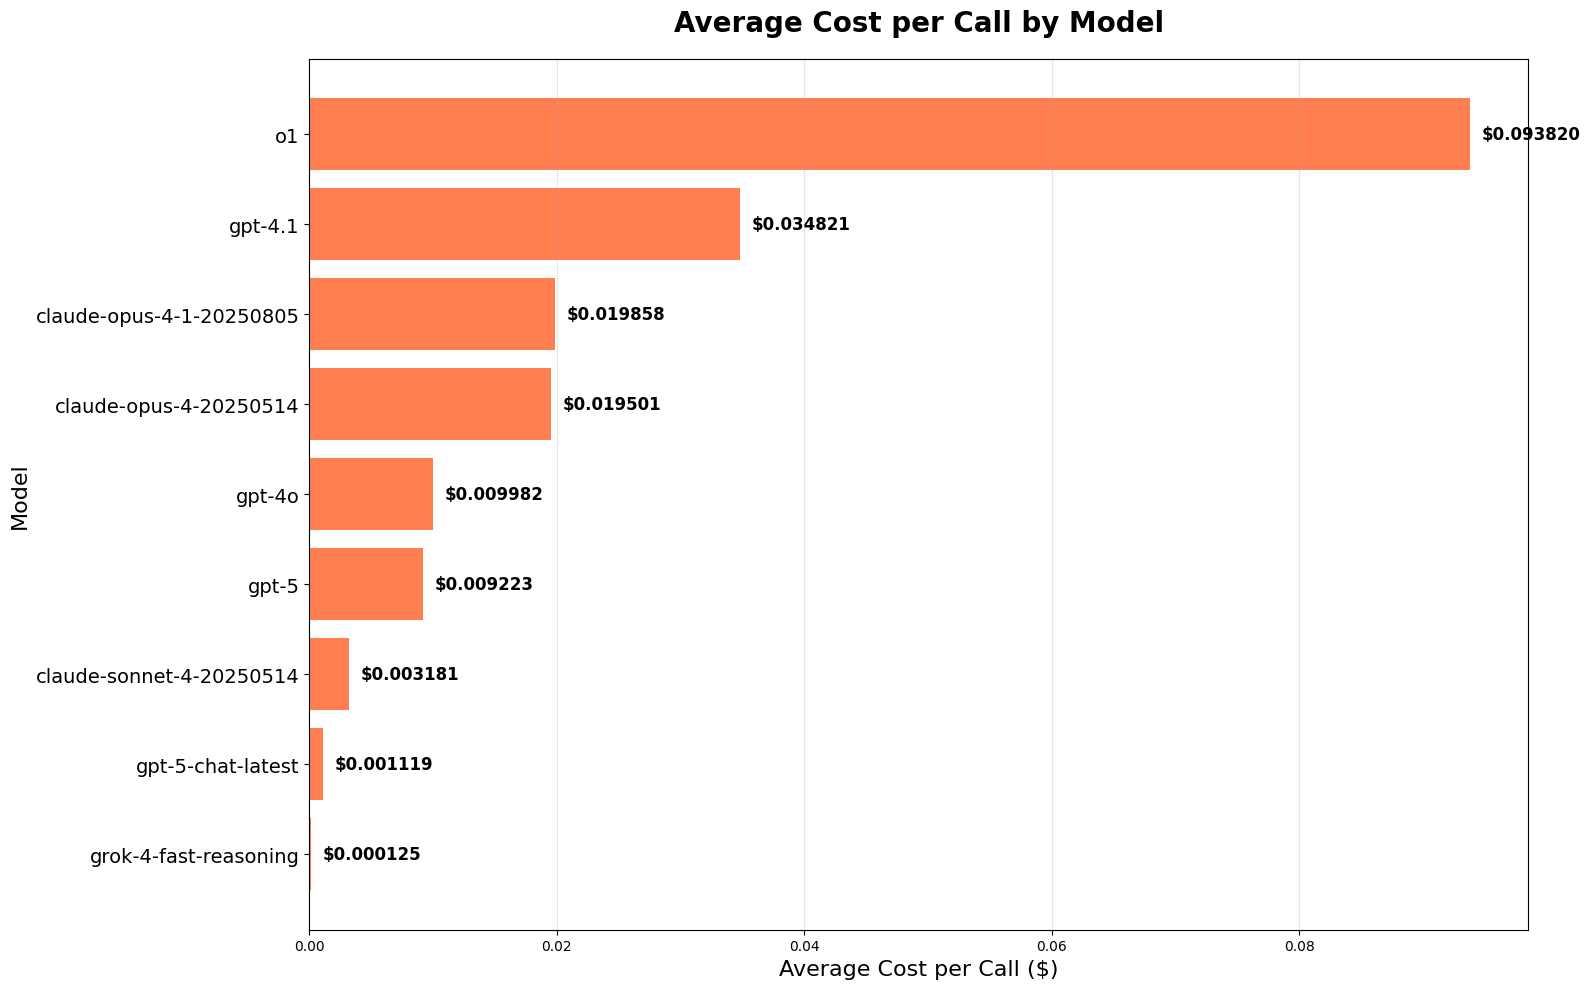

Saved average cost per call plot to: reports/plots/bf_average_cost_per_call.png


In [58]:
# Plot average cost per call by model
print("\n=== Creating average cost per call plot ===")

# Extract average total cost for each model and sort
avg_cost_data = cost_df['avg_total_cost'].sort_values(ascending=True)

# Create the plot
fig, ax = plt.subplots(figsize=(16, 10))

bars = ax.barh(range(len(avg_cost_data)), avg_cost_data.values, color='coral')
ax.set_title('Average Cost per Call by Model', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Average Cost per Call ($)', fontsize=16)
ax.set_ylabel('Model', fontsize=16)
ax.set_yticks(range(len(avg_cost_data)))
ax.set_yticklabels(avg_cost_data.index, fontsize=14)
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, avg_cost_data.values)):
    ax.text(value + max(avg_cost_data.values) * 0.01, i, f'${value:.6f}', 
            ha='left', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()

# Ensure the directory exists
Path('reports/plots').mkdir(parents=True, exist_ok=True)

plt.savefig('reports/plots/bf_average_cost_per_call.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved average cost per call plot to: reports/plots/bf_average_cost_per_call.png")

In [53]:
accuracy_df.set_index('model', inplace=True)

In [59]:
# Create scatter plots for cost vs accuracy and tokens vs accuracy
print("=== Creating Scatter Plots: Cost vs Accuracy and Tokens vs Accuracy ===")

# Combine all metrics into a single dataframe for scatter plots
scatter_data = []

for model_name in accuracy_df.index:
    if model_name in cost_df.index:
        # Get accuracy
        accuracy = accuracy_df.loc[model_name, 'accuracy']
        
        # Get cost data
        avg_total_cost = cost_df.loc[model_name, 'avg_total_cost']
        
        # Get token data
        avg_input_tokens = input_token_df.loc[model_name, 'avg_input_tokens']
        avg_output_tokens = output_token_df.loc[model_name, 'avg_output_tokens']
        avg_total_tokens = avg_input_tokens + avg_output_tokens
        
        scatter_data.append({
            'model_name': model_name,
            'accuracy': accuracy,
            'avg_total_cost': avg_total_cost,
            'avg_input_tokens': avg_input_tokens,
            'avg_output_tokens': avg_output_tokens,
            'avg_total_tokens': avg_total_tokens
        })

# Convert to DataFrame
scatter_df = pd.DataFrame(scatter_data)

=== Creating Scatter Plots: Cost vs Accuracy and Tokens vs Accuracy ===


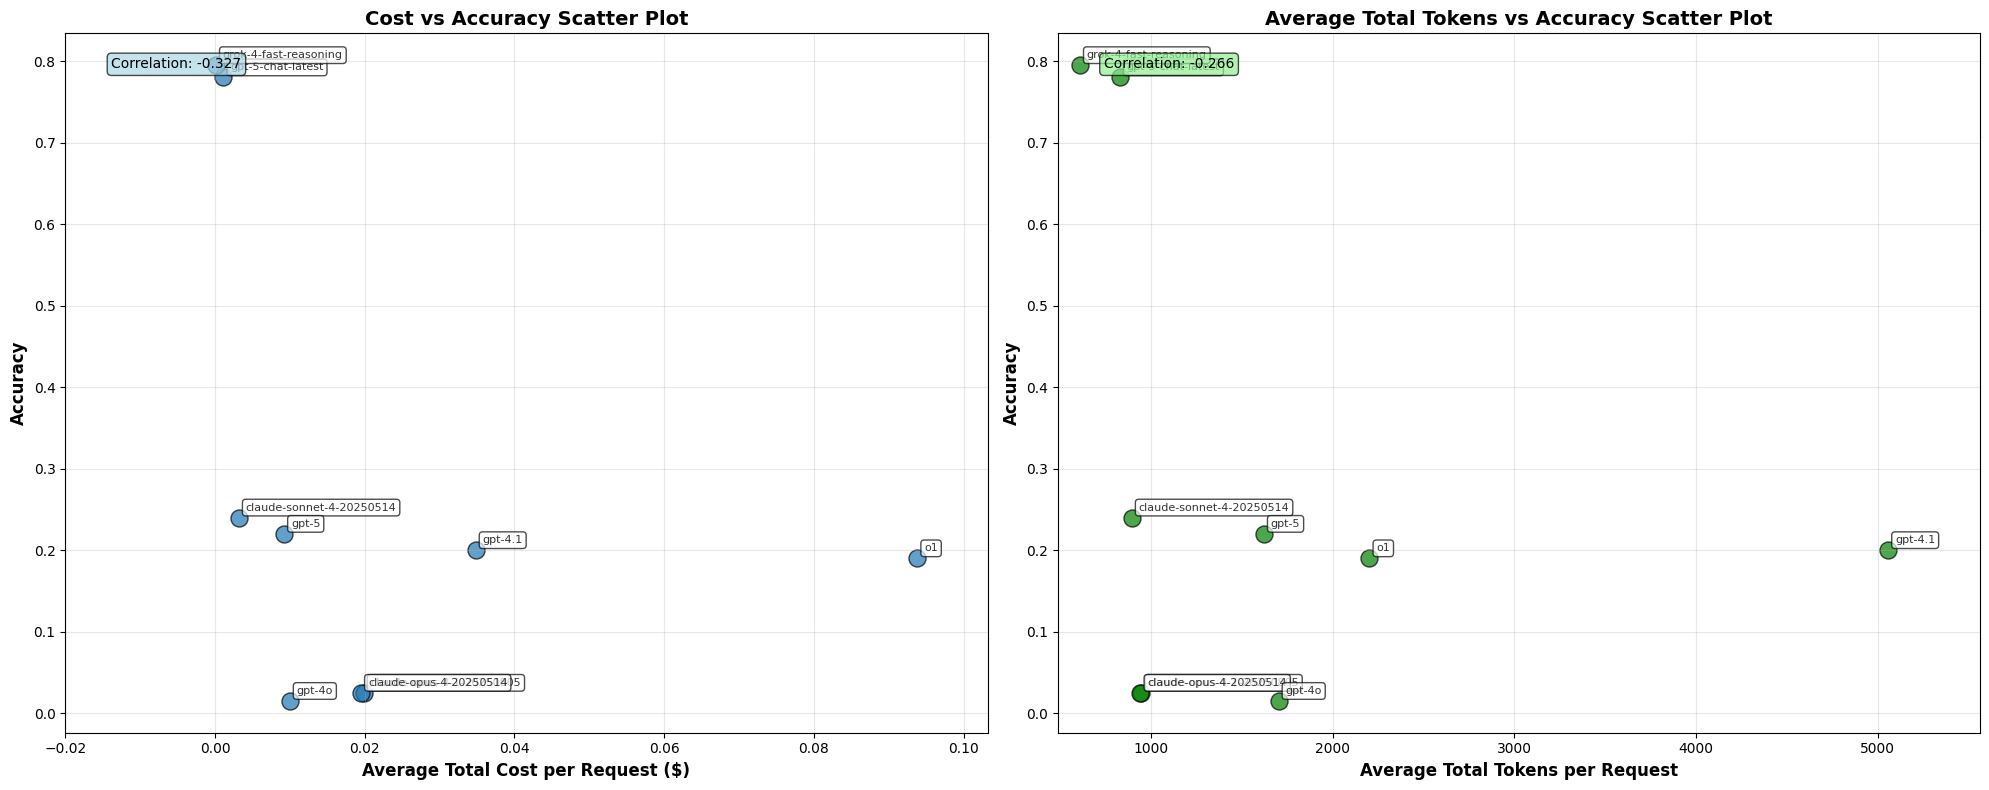

Saved scatter plots to: reports/plots/bf_cost_tokens_vs_accuracy_scatter.png
Cost vs Accuracy correlation: -0.327
Tokens vs Accuracy correlation: -0.266


In [60]:
# Create scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Cost vs Accuracy
ax1.scatter(scatter_df['avg_total_cost'], scatter_df['accuracy'], 
           s=150, alpha=0.7, edgecolors='black', linewidth=1)

# Add model labels
for i, model in enumerate(scatter_df['model_name']):
    ax1.annotate(model, 
                (scatter_df['avg_total_cost'].iloc[i], scatter_df['accuracy'].iloc[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax1.set_xlabel('Average Total Cost per Request ($)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Cost vs Accuracy Scatter Plot', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-0.02, scatter_df['avg_total_cost'].max() * 1.1])

# Add correlation coefficient
correlation_cost = scatter_df['avg_total_cost'].corr(scatter_df['accuracy'])
ax1.text(0.05, 0.95, f'Correlation: {correlation_cost:.3f}', 
         transform=ax1.transAxes, fontsize=10, 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))

# Plot 2: Average Total Tokens vs Accuracy
ax2.scatter(scatter_df['avg_total_tokens'], scatter_df['accuracy'], 
           s=150, alpha=0.7, edgecolors='black', linewidth=1, color='green')

# Add model labels
for i, model in enumerate(scatter_df['model_name']):
    ax2.annotate(model, 
                (scatter_df['avg_total_tokens'].iloc[i], scatter_df['accuracy'].iloc[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax2.set_xlabel('Average Total Tokens per Request', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Average Total Tokens vs Accuracy Scatter Plot', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([scatter_df['avg_total_tokens'].min() * 0.8, scatter_df['avg_total_tokens'].max() * 1.1])

# Add correlation coefficient
correlation_tokens = scatter_df['avg_total_tokens'].corr(scatter_df['accuracy'])
ax2.text(0.05, 0.95, f'Correlation: {correlation_tokens:.3f}', 
         transform=ax2.transAxes, fontsize=10, 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.savefig('reports/plots/bf_cost_tokens_vs_accuracy_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved scatter plots to: reports/plots/bf_cost_tokens_vs_accuracy_scatter.png")
print(f"Cost vs Accuracy correlation: {correlation_cost:.3f}")
print(f"Tokens vs Accuracy correlation: {correlation_tokens:.3f}")

# Self-Consistency Analysis

This section analyzes the self-consistency of each model by comparing responses between two separate runs (v1 and v2) on the same input.

In [62]:
# Calculate self-consistency metrics for each model
print("=== Self-Consistency Analysis ===")

consistency_metrics = {}

for model_name in comparison_df['model_name'].unique():
    model_data = comparison_df[comparison_df['model_name'] == model_name].copy()
    
    print(f"\n{model_name}:")
    print(f"  Total comparison pairs: {len(model_data)}")
    
    # Filter for cases where both predictions are available
    valid_pairs = model_data[
        (model_data['v1_parsed_success'] == True) & 
        (model_data['v2_parsed_success'] == True)
    ].copy()
    
    # Calculate consistency metrics
    v1_preds = pd.Series([int(i["v1_prediction"]) if i["v1_parsed_success"] == True else -1 for _, i in model_data.iterrows()]).astype(int)
    v2_preds = pd.Series([int(i["v2_prediction"]) if i["v2_parsed_success"] == True else -2 for _, i in model_data.iterrows()]).astype(int)
    
    # Exact match consistency
    exact_matches = (v1_preds == v2_preds).sum()
    exact_consistency = exact_matches / len(model_data)
    
    # Response text similarity (exact match)
    text_matches = (model_data['v1_response_text'] == model_data['v2_response_text']).sum()
    text_consistency = text_matches / len(model_data)
    
    # Latency consistency (correlation)
    latency_correlation = model_data['v1_latency'].corr(model_data['v2_latency'])
    
    # Prediction distribution comparison
    v1_dist = v1_preds.value_counts().sort_index()
    v2_dist = v2_preds.value_counts().sort_index()
    
    # Chi-square test for distribution similarity
    from scipy.stats import chi2_contingency
    contingency_table = pd.crosstab(v1_preds, v2_preds)
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    consistency_metrics[model_name] = {
        'total_pairs': len(model_data),
        'valid_pairs': len(valid_pairs),
        'exact_consistency': exact_consistency,
        'text_consistency': text_consistency,
        'latency_correlation': latency_correlation,
        'chi2_statistic': chi2,
        'chi2_p_value': p_value,
        'v1_pred_0': v1_dist.get(0, 0),
        'v1_pred_1': v1_dist.get(1, 0),
        'v2_pred_0': v2_dist.get(0, 0),
        'v2_pred_1': v2_dist.get(1, 0)
    }
    
    print(f"  Exact prediction consistency: {exact_consistency:.3f} ({exact_matches}/{len(model_data)})")
    print(f"  Response text consistency: {text_consistency:.3f} ({text_matches}/{len(model_data)})")
    print(f"  Latency correlation: {latency_correlation:.3f}")
    print(f"  Chi-square p-value: {p_value:.6f}")
    print(f"  V1 predictions: 0={v1_dist.get(0, 0)}, 1={v1_dist.get(1, 0)}")
    print(f"  V2 predictions: 0={v2_dist.get(0, 0)}, 1={v2_dist.get(1, 0)}")
   
# Convert to DataFrame
consistency_df = pd.DataFrame(consistency_metrics).T
print(f"\n=== Consistency Metrics Summary ===")
print(consistency_df[['valid_pairs', 'exact_consistency', 'text_consistency', 'latency_correlation', 'chi2_p_value']])
consistency_df.to_csv('reports/csv_reports/bf_model_consistency_metrics.csv')
print("Saved consistency metrics data to: reports/csv_reports/bf_model_consistency_metrics.csv")

=== Self-Consistency Analysis ===

claude-3-7-sonnet-20250219:
  Total comparison pairs: 100
  Exact prediction consistency: 0.840 (84/100)
  Response text consistency: 0.840 (84/100)
  Latency correlation: -0.115
  Chi-square p-value: 0.000000
  V1 predictions: 0=23, 1=77
  V2 predictions: 0=27, 1=73

claude-opus-4-1-20250805:
  Total comparison pairs: 100
  Exact prediction consistency: 0.060 (6/100)
  Response text consistency: 0.060 (6/100)
  Latency correlation: 0.041
  Chi-square p-value: 0.310391
  V1 predictions: 0=17, 1=2
  V2 predictions: 0=18, 1=2

claude-opus-4-20250514:
  Total comparison pairs: 100
  Exact prediction consistency: 0.070 (7/100)
  Response text consistency: 0.070 (7/100)
  Latency correlation: 0.118
  Chi-square p-value: 0.541507
  V1 predictions: 0=24, 1=0
  V2 predictions: 0=23, 1=2

claude-sonnet-4-20250514:
  Total comparison pairs: 100
  Exact prediction consistency: 0.510 (51/100)
  Response text consistency: 0.510 (51/100)
  Latency correlation: 0.32

=== Creating Self-Consistency Visualizations ===


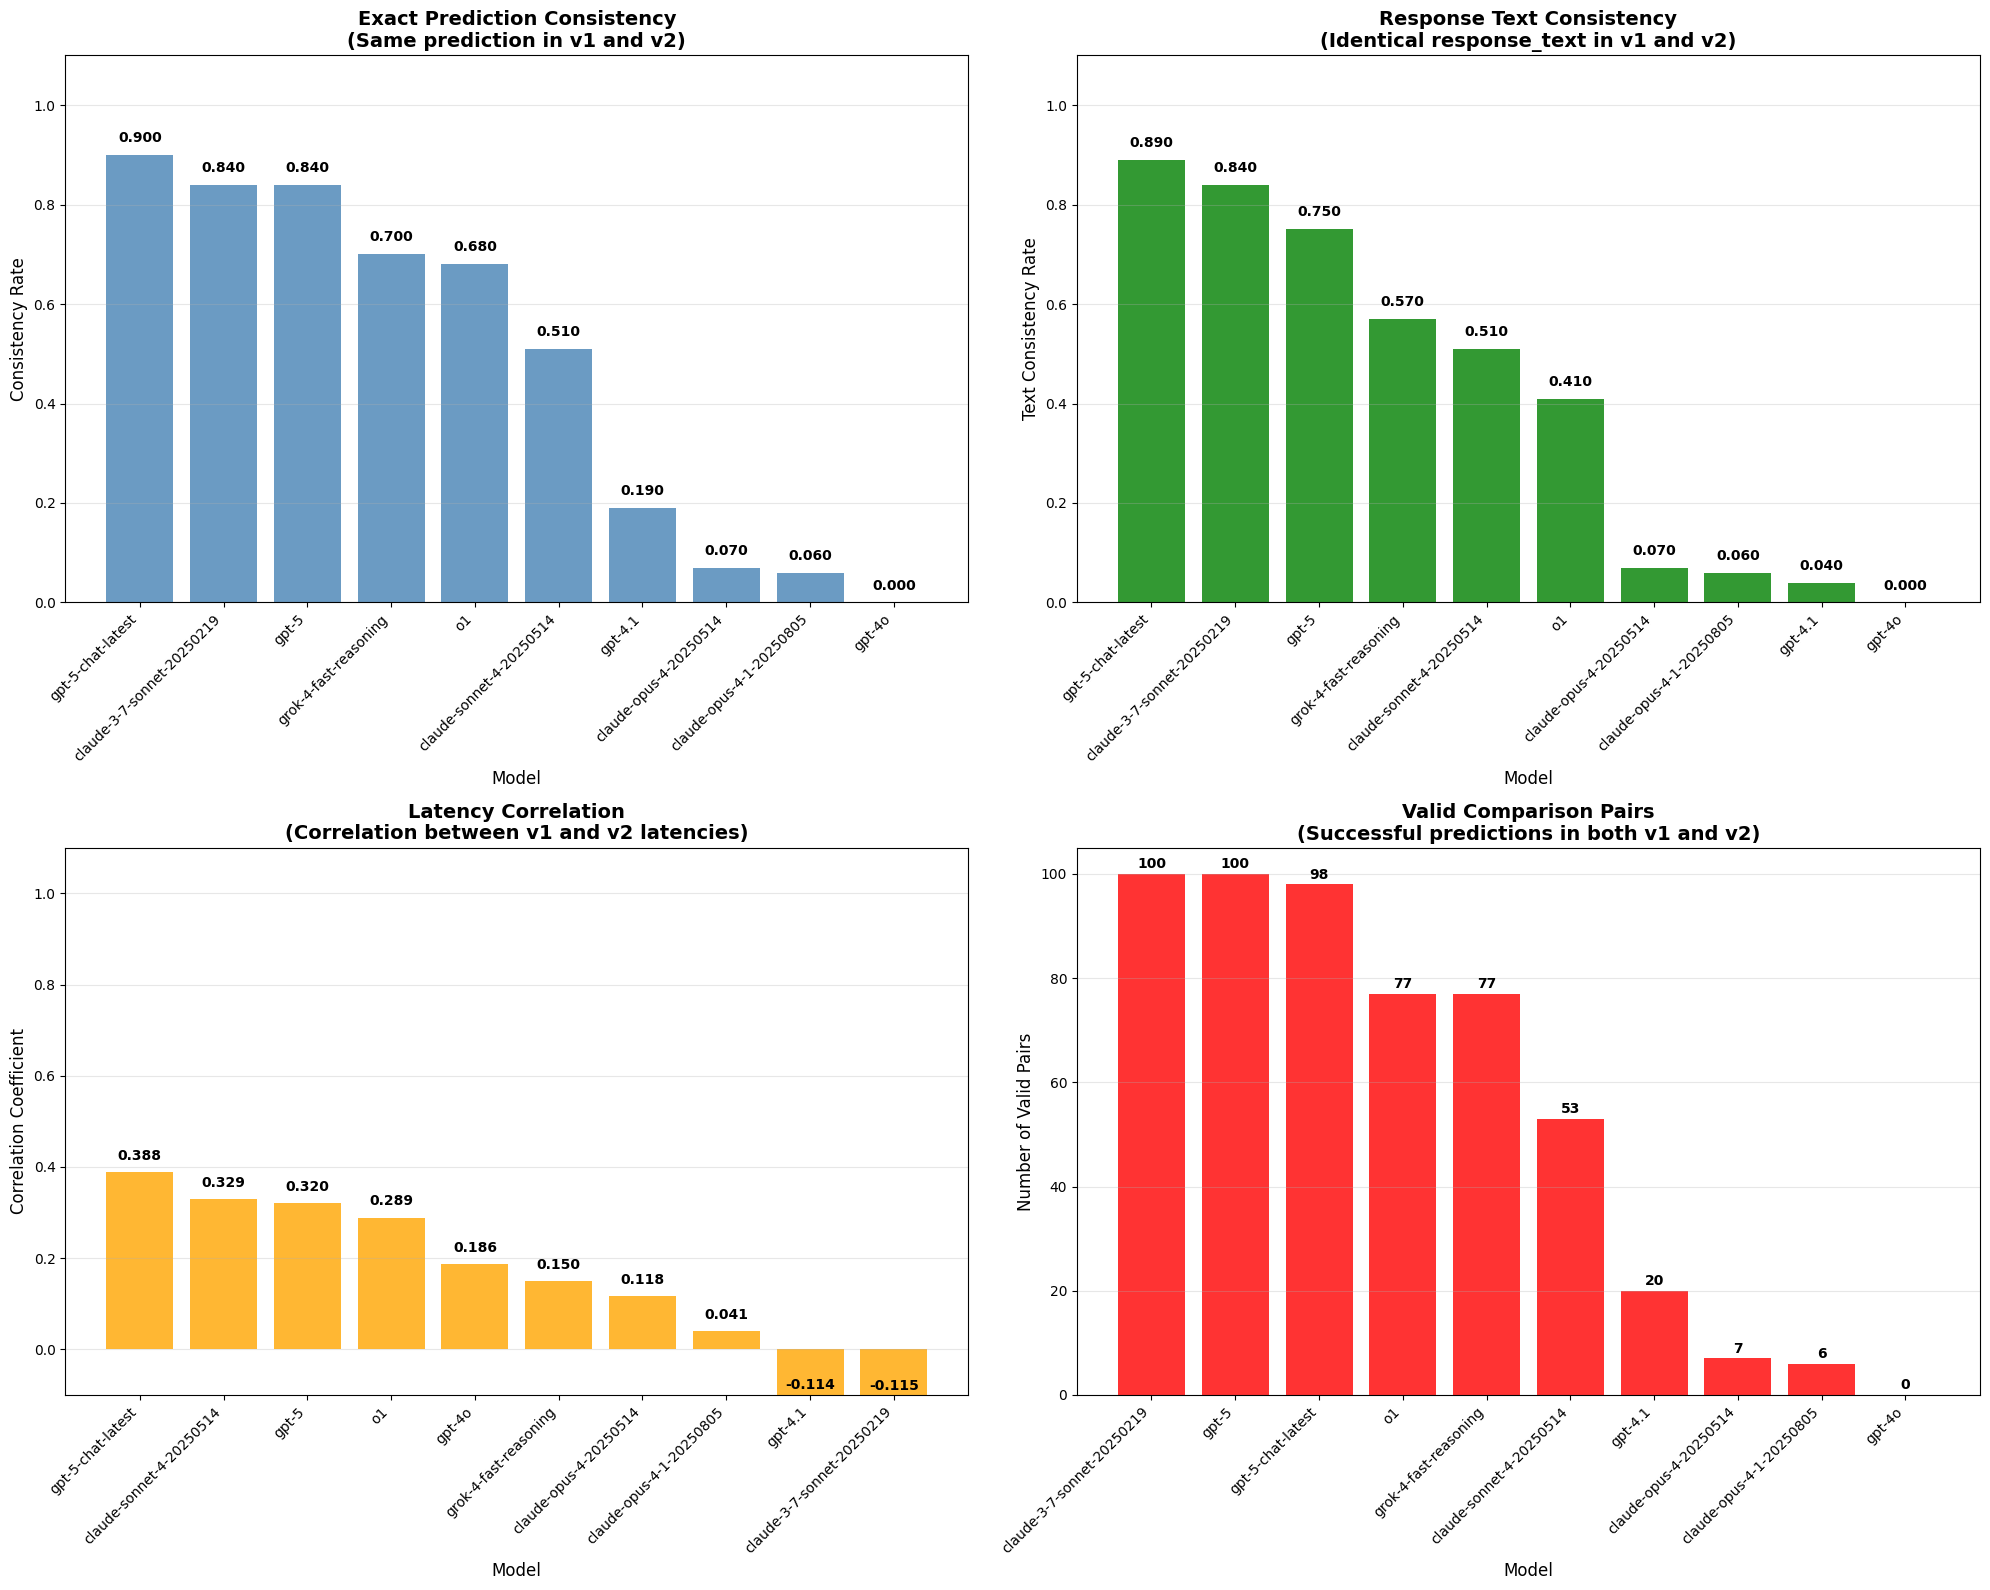

Saved self-consistency analysis plots to: reports/plots/bf_model_self_consistency_analysis.png


In [63]:
# Create visualizations for self-consistency analysis
print("=== Creating Self-Consistency Visualizations ===")

# Create a comprehensive consistency analysis plot
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Exact Prediction Consistency
ax1 = axes[0, 0]
exact_consistency_data = consistency_df['exact_consistency'].dropna().sort_values(ascending=False)
bars1 = ax1.bar(range(len(exact_consistency_data)), exact_consistency_data.values, 
               color='steelblue', alpha=0.8)
ax1.set_title('Exact Prediction Consistency\n(Same prediction in v1 and v2)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Consistency Rate', fontsize=12)
ax1.set_xticks(range(len(exact_consistency_data)))
ax1.set_xticklabels(exact_consistency_data.index, rotation=45, ha='right')
ax1.set_ylim([0, 1.1])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars1, exact_consistency_data.values)):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Response Text Consistency
ax2 = axes[0, 1]
text_consistency_data = consistency_df['text_consistency'].dropna().sort_values(ascending=False)
bars2 = ax2.bar(range(len(text_consistency_data)), text_consistency_data.values, 
               color='green', alpha=0.8)
ax2.set_title('Response Text Consistency\n(Identical response_text in v1 and v2)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('Text Consistency Rate', fontsize=12)
ax2.set_xticks(range(len(text_consistency_data)))
ax2.set_xticklabels(text_consistency_data.index, rotation=45, ha='right')
ax2.set_ylim([0, 1.1])
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars2, text_consistency_data.values)):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Latency Correlation
ax3 = axes[1, 0]
latency_corr_data = consistency_df['latency_correlation'].dropna().sort_values(ascending=False)
bars3 = ax3.bar(range(len(latency_corr_data)), latency_corr_data.values, 
               color='orange', alpha=0.8)
ax3.set_title('Latency Correlation\n(Correlation between v1 and v2 latencies)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Model', fontsize=12)
ax3.set_ylabel('Correlation Coefficient', fontsize=12)
ax3.set_xticks(range(len(latency_corr_data)))
ax3.set_xticklabels(latency_corr_data.index, rotation=45, ha='right')
ax3.set_ylim([-0.1, 1.1])
ax3.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars3, latency_corr_data.values)):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Valid Pairs Count
ax4 = axes[1, 1]
valid_pairs_data = consistency_df['valid_pairs'].sort_values(ascending=False)
bars4 = ax4.bar(range(len(valid_pairs_data)), valid_pairs_data.values, 
               color='red', alpha=0.8)
ax4.set_title('Valid Comparison Pairs\n(Successful predictions in both v1 and v2)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Model', fontsize=12)
ax4.set_ylabel('Number of Valid Pairs', fontsize=12)
ax4.set_xticks(range(len(valid_pairs_data)))
ax4.set_xticklabels(valid_pairs_data.index, rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars4, valid_pairs_data.values)):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{int(value)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/plots/bf_model_self_consistency_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved self-consistency analysis plots to: reports/plots/bf_model_self_consistency_analysis.png")

=== Creating Consistency Heatmaps ===


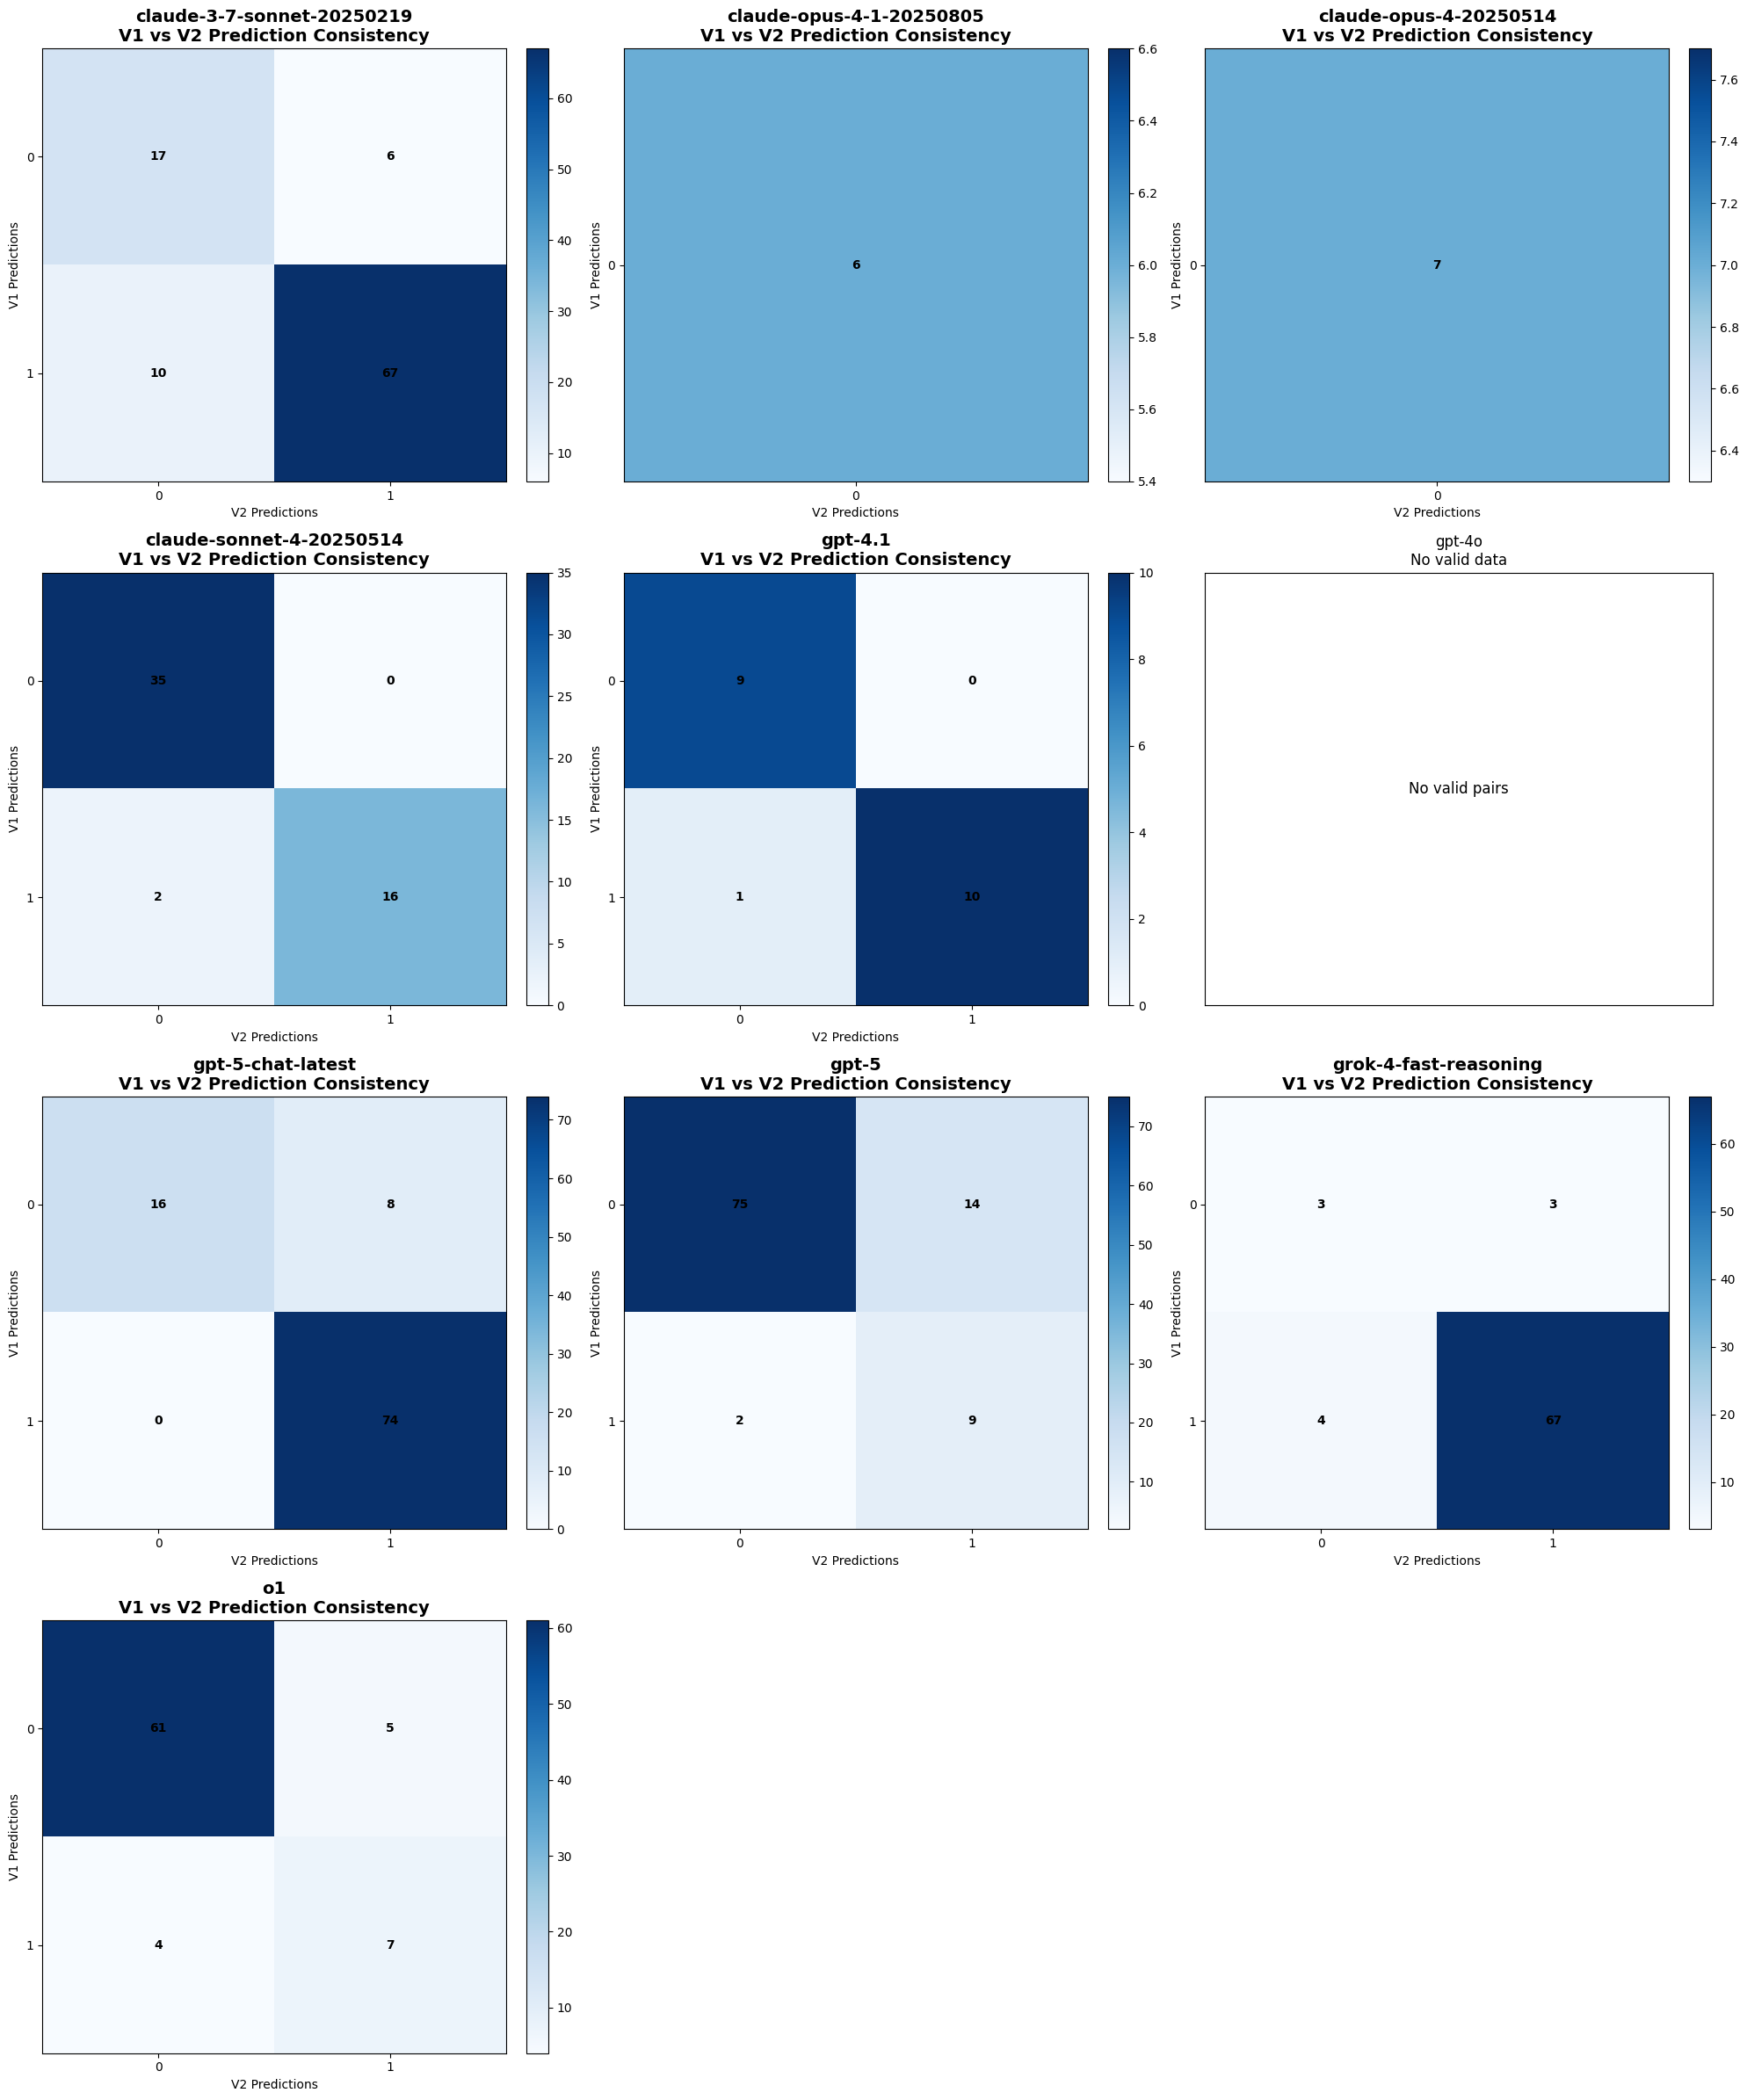

Saved consistency heatmaps to: reports/plots/bf_model_consistency_heatmaps.png


In [64]:
# Create detailed consistency heatmaps for each model
print("=== Creating Consistency Heatmaps ===")

# Create a figure with subplots for each model
n_models = len(consistency_df)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for idx, (model_name, model_data) in enumerate(consistency_df.iterrows()):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]
    
    # Get comparison data for this model
    model_comparison = comparison_df[comparison_df['model_name'] == model_name]
    valid_pairs = model_comparison[
        (model_comparison['v1_parsed_success'] == True) & 
        (model_comparison['v2_parsed_success'] == True)
    ]
    
    if len(valid_pairs) > 0:
        # Create confusion matrix for v1 vs v2 predictions
        v1_preds = valid_pairs['v1_prediction'].astype(int)
        v2_preds = valid_pairs['v2_prediction'].astype(int)
        
        # Create contingency table
        contingency_table = pd.crosstab(v1_preds, v2_preds, rownames=['V1'], colnames=['V2'])
        
        # Plot heatmap
        im = ax.imshow(contingency_table.values, cmap='Blues', aspect='auto')
        
        # Add text annotations
        for i in range(contingency_table.shape[0]):
            for j in range(contingency_table.shape[1]):
                ax.text(j, i, f"{contingency_table.iloc[i, j]}", 
                       ha="center", va="center", color="black", fontweight='bold')
        
        # Set labels
        ax.set_xticks(range(contingency_table.shape[1]))
        ax.set_yticks(range(contingency_table.shape[0]))
        ax.set_xticklabels(contingency_table.columns)
        ax.set_yticklabels(contingency_table.index)
        ax.set_xlabel('V2 Predictions')
        ax.set_ylabel('V1 Predictions')
        ax.set_title(f'{model_name}\nV1 vs V2 Prediction Consistency', fontsize=14, fontweight='bold')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.text(0.5, 0.5, 'No valid pairs', ha='center', va='center', 
               transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{model_name}\nNo valid data')
        ax.set_xticks([])
        ax.set_yticks([])

# Hide empty subplots
for idx in range(n_models, n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.savefig('reports/plots/bf_model_consistency_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved consistency heatmaps to: reports/plots/bf_model_consistency_heatmaps.png")

In [65]:
# Detailed response text comparison analysis
print("=== Response Text Comparison Analysis ===")

# Analyze cases where predictions match but text differs
text_analysis = []

for model_name in comparison_df['model_name'].unique():
    model_data = comparison_df[comparison_df['model_name'] == model_name]
    valid_pairs = model_data[
        (model_data['v1_parsed_success'] == True) & 
        (model_data['v2_parsed_success'] == True)
    ]

    
    # Cases where predictions match but text differs
    pred_match_text_diff = model_data[
    (model_data['v1_parsed_success'] == True) &
    (model_data['v2_parsed_success'] == True) &
    (model_data['v1_prediction'] == model_data['v2_prediction']) &
    (model_data['v1_response_text'] != model_data['v2_response_text'])
]
    
    # Cases where predictions differ but text is same
    pred_diff_text_match = model_data[((((model_data['v1_parsed_success'] == True) & (model_data['v2_parsed_success'] == True)) & (model_data['v1_prediction'] != model_data['v2_prediction'])) | ((model_data['v1_parsed_success'] == False) | (model_data['v2_parsed_success'] == False))) & (model_data['v1_response_text'] == model_data['v2_response_text'])
    ]

    print(pred_diff_text_match)
    
    # Cases where both predictions and text match
    both_match = model_data[(model_data['v1_parsed_success'] == True) &
    (model_data['v2_parsed_success'] == True) &
        (model_data['v1_prediction'] == model_data['v2_prediction']) &
        (model_data['v1_response_text'] == model_data['v2_response_text'])
    ]
        
    # Cases where both predictions and text differ
    both_diff = model_data[
        ((((model_data['v1_parsed_success'] == True) & (model_data['v2_parsed_success'] == True)) & (model_data['v1_prediction'] != model_data['v2_prediction'])) | ((model_data['v1_parsed_success'] == False) | (model_data['v2_parsed_success'] == False))) &
        (model_data['v1_response_text'] != model_data['v2_response_text'])
    ]
    
    text_analysis.append({
        'model_name': model_name,
        'total_valid_pairs': len(valid_pairs),
        'pred_match_text_diff': len(pred_match_text_diff),
        'pred_diff_text_match': len(pred_diff_text_match),
        'both_match': len(both_match),
        'both_diff': len(both_diff),
        'pred_match_text_diff_pct': len(pred_match_text_diff) / len(model_data) * 100,
        'pred_diff_text_match_pct': len(pred_diff_text_match) / len(model_data) * 100,
        'both_match_pct': len(both_match) / len(model_data) * 100,
        'both_diff_pct': len(both_diff) / len(model_data) * 100
    })
    
    print(f"\n{model_name}:")
    print(f"  Total valid pairs: {len(valid_pairs)}")
    print(f"  Prediction match, text differ: {len(pred_match_text_diff)} ({len(pred_match_text_diff)/len(model_data)*100:.1f}%)")
    print(f"  Prediction differ, text match: {len(pred_diff_text_match)} ({len(pred_diff_text_match)/len(model_data)*100:.1f}%)")
    print(f"  Both match: {len(both_match)} ({len(both_match)/len(model_data)*100:.1f}%)")
    print(f"  Both differ: {len(both_diff)} ({len(both_diff)/len(model_data)*100:.1f}%)")

# Convert to DataFrame
text_analysis_df = pd.DataFrame(text_analysis)
print(f"\n=== Text Analysis Summary ===")
print(text_analysis_df[['model_name', 'total_valid_pairs', 'both_match_pct', 'pred_match_text_diff_pct', 'pred_diff_text_match_pct', 'both_diff_pct']])

# Save to CSV
text_analysis_df.to_csv('reports/csv_reports/bf_model_response_text_comparison_analysis.csv', index=False)
print("Saved response text comparison analysis to: reports/csv_reports/bf_model_response_text_comparison_analysis.csv")

=== Response Text Comparison Analysis ===
Empty DataFrame
Columns: [model_name, experiment_id, v1_prediction, v2_prediction, v1_response_text, v2_response_text, v1_parsed_success, v2_parsed_success, v1_latency, v2_latency]
Index: []

claude-3-7-sonnet-20250219:
  Total valid pairs: 100
  Prediction match, text differ: 0 (0.0%)
  Prediction differ, text match: 0 (0.0%)
  Both match: 84 (84.0%)
  Both differ: 16 (16.0%)
Empty DataFrame
Columns: [model_name, experiment_id, v1_prediction, v2_prediction, v1_response_text, v2_response_text, v1_parsed_success, v2_parsed_success, v1_latency, v2_latency]
Index: []

claude-opus-4-1-20250805:
  Total valid pairs: 6
  Prediction match, text differ: 0 (0.0%)
  Prediction differ, text match: 0 (0.0%)
  Both match: 6 (6.0%)
  Both differ: 94 (94.0%)
Empty DataFrame
Columns: [model_name, experiment_id, v1_prediction, v2_prediction, v1_response_text, v2_response_text, v1_parsed_success, v2_parsed_success, v1_latency, v2_latency]
Index: []

claude-opus-

=== Creating Text Consistency Pattern Visualization ===


C:\Users\nguyetpvt\AppData\Local\Temp\ipykernel_24416\1808912324.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=45, ha='right')


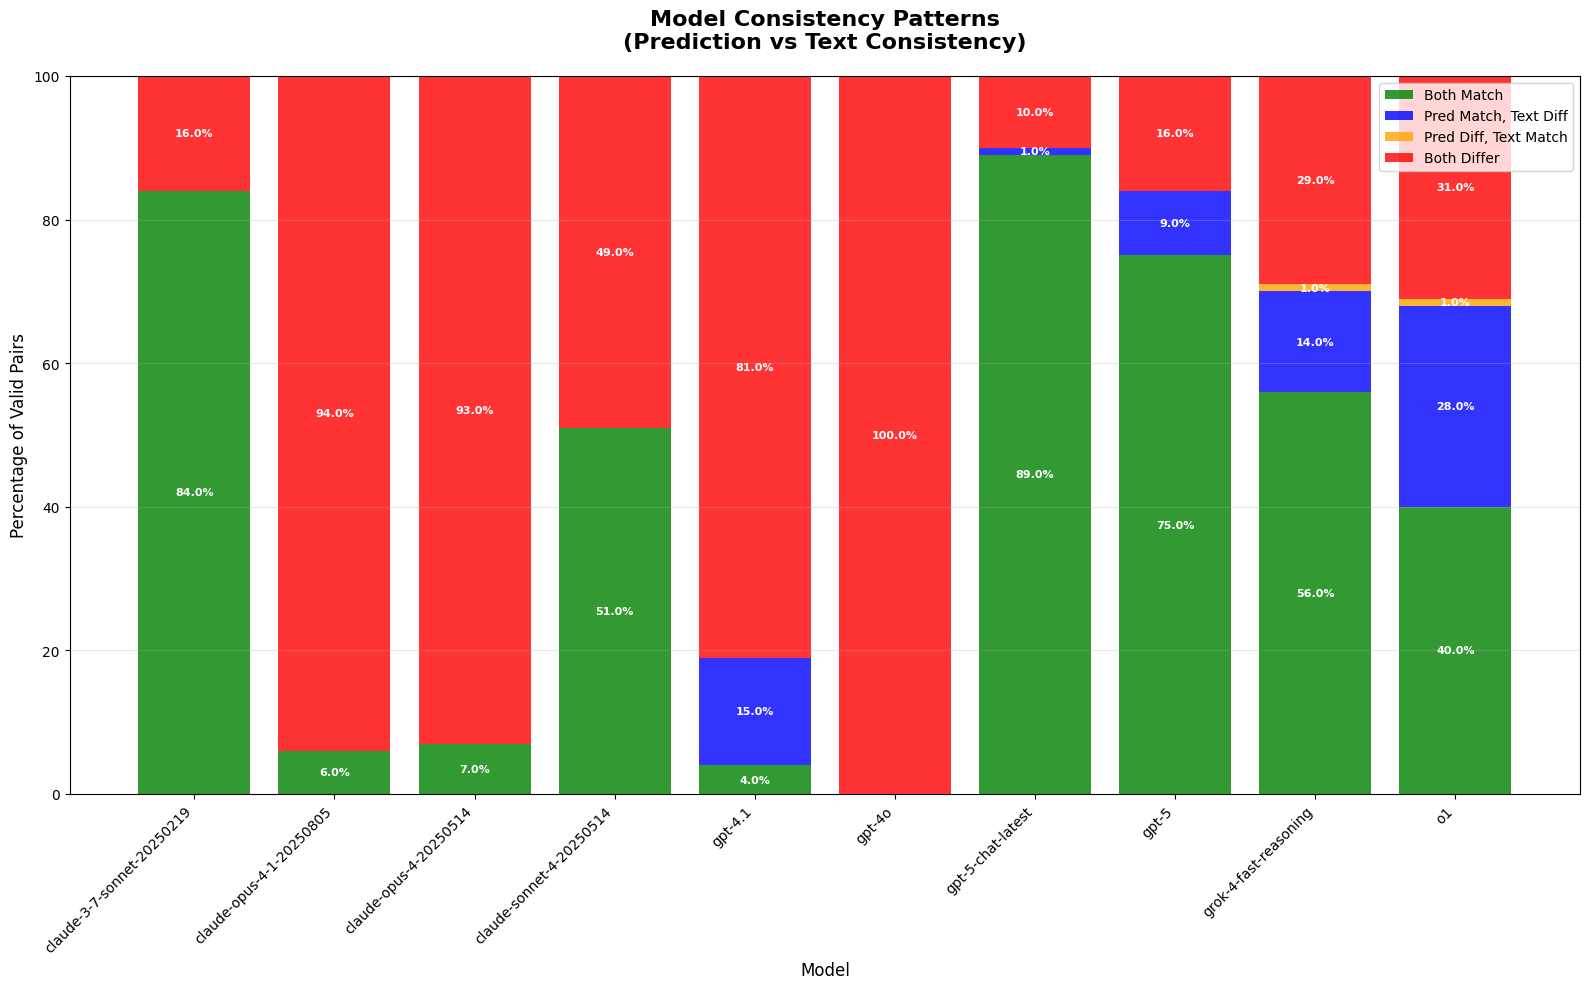

Saved text consistency patterns plot to: reports/plots/bf_model_text_consistency_patterns.png


In [66]:
# Create visualization for text consistency patterns
print("=== Creating Text Consistency Pattern Visualization ===")

# Create a stacked bar chart showing the different consistency patterns
fig, ax = plt.subplots(figsize=(16, 10))

# Prepare data for stacked bar chart
models = text_analysis_df['model_name']
both_match = text_analysis_df['both_match_pct']
pred_match_text_diff = text_analysis_df['pred_match_text_diff_pct']
pred_diff_text_match = text_analysis_df['pred_diff_text_match_pct']
both_diff = text_analysis_df['both_diff_pct']

# Create stacked bars
bars_both_match = ax.bar(models, both_match, color='green', alpha=0.8, label='Both Match')
bars_pred_match_text_diff = ax.bar(models, pred_match_text_diff, bottom=both_match, 
                                   color='blue', alpha=0.8, label='Pred Match, Text Diff')
bars_pred_diff_text_match = ax.bar(models, pred_diff_text_match, 
                                  bottom=both_match + pred_match_text_diff,
                                  color='orange', alpha=0.8, label='Pred Diff, Text Match')
bars_both_diff = ax.bar(models, both_diff, 
                        bottom=both_match + pred_match_text_diff + pred_diff_text_match,
                        color='red', alpha=0.8, label='Both Differ')

# Add value labels on bars
for i, (model, both_m, pred_m_text_d, pred_d_text_m, both_d) in enumerate(zip(models, both_match, pred_match_text_diff, pred_diff_text_match, both_diff)):
    # Label for both match
    if both_m > 0:
        ax.text(i, both_m/2, f'{both_m:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    
    # Label for pred match text diff
    if pred_m_text_d > 0:
        ax.text(i, both_m + pred_m_text_d/2, f'{pred_m_text_d:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    
    # Label for pred diff text match
    if pred_d_text_m > 0:
        ax.text(i, both_m + pred_m_text_d + pred_d_text_m/2, f'{pred_d_text_m:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    
    # Label for both diff
    if both_d > 0:
        ax.text(i, both_m + pred_m_text_d + pred_d_text_m + both_d/2, f'{both_d:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')

ax.set_title('Model Consistency Patterns\n(Prediction vs Text Consistency)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Percentage of Valid Pairs', fontsize=12)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('reports/plots/bf_model_text_consistency_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved text consistency patterns plot to: reports/plots/bf_model_text_consistency_patterns.png")

In [67]:
# Save all consistency analysis results
print("=== Saving Consistency Analysis Results ===")

# Save consistency metrics
consistency_df.to_csv('reports/csv_reports/bf_model_self_consistency_metrics.csv')
print("Saved consistency metrics to: reports/csv_reports/bf_model_self_consistency_metrics.csv")

# Save text analysis
text_analysis_df.to_csv('reports/csv_reports/bf_model_text_consistency_analysis.csv')
print("Saved text analysis to: reports/csv_reports/bf_model_text_consistency_analysis.csv")

# Save detailed comparison data
comparison_df.to_csv('reports/csv_reports/bf_model_v1_v2_comparison.csv', index=False)
print("Saved detailed comparison data to: reports/csv_reports/bf_model_v1_v2_comparison.csv")
print("\n=== Self-Consistency Analysis Summary ===")
print("Key findings:")
print(f"- Total models analyzed: {len(consistency_df)}")
print(f"- Average exact prediction consistency: {consistency_df['exact_consistency'].mean():.3f}")
print(f"- Average text consistency: {consistency_df['text_consistency'].mean():.3f}")
print(f"- Average latency correlation: {consistency_df['latency_correlation'].mean():.3f}")

# Find most and least consistent models
most_consistent = consistency_df['exact_consistency'].idxmax()
least_consistent = consistency_df['exact_consistency'].idxmin()
print(f"- Most consistent model: {most_consistent} ({consistency_df.loc[most_consistent, 'exact_consistency']:.3f})")
print(f"- Least consistent model: {least_consistent} ({consistency_df.loc[least_consistent, 'exact_consistency']:.3f})")

print("\n=== Analysis Complete ===")
print("All consistency analysis plots and data have been saved to the reports directory.")

=== Saving Consistency Analysis Results ===
Saved consistency metrics to: reports/csv_reports/bf_model_self_consistency_metrics.csv
Saved text analysis to: reports/csv_reports/bf_model_text_consistency_analysis.csv
Saved detailed comparison data to: reports/csv_reports/bf_model_v1_v2_comparison.csv

=== Self-Consistency Analysis Summary ===
Key findings:
- Total models analyzed: 10
- Average exact prediction consistency: 0.479
- Average text consistency: 0.414
- Average latency correlation: 0.159
- Most consistent model: gpt-5-chat-latest (0.900)
- Least consistent model: gpt-4o (0.000)

=== Analysis Complete ===
All consistency analysis plots and data have been saved to the reports directory.
